# 03 — Exploratory Data Analysis
## EV Population Dataset — Washington State

**Project:** Data Visualisation & Analytics — Team Project  
**Notebook:** 03 of 05  
**Objective:** Understand the structure, distributions, trends, and outliers in the cleaned EV registration dataset before modelling and KPI computation.

---

### Table of Contents
1. [Setup & Data Load](#1)
2. [Dataset Overview](#2)
3. [Univariate Analysis — Numeric Columns](#3)
4. [Univariate Analysis — Categorical Columns](#4)
5. [Bivariate & Group Analysis](#5)
6. [Trend Analysis — Model Year](#6)
7. [Geographic Concentration](#7)
8. [Outlier Detection](#8)
9. [Key EDA Findings Summary](#9)

---
## 1. Setup & Data Load <a id='1'></a>

In [ ]:
import numpy as np
import pandas as pd

# Display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.width', 120)

# Load cleaned dataset
DATA_PATH = 'EV_Population_Cleaned.csv'
df = pd.read_csv(DATA_PATH)

print(f'Dataset loaded successfully — {df.shape[0]:,} rows × {df.shape[1]} columns')

: 

---
## 2. Dataset Overview <a id='2'></a>

In [ ]:
# ----- 2.1 Shape & Column Inventory -----
print('=== Shape ===')
print(f'Rows   : {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print()

print('=== Column Names & Data Types ===')
print(df.dtypes.to_string())

=== Shape ===
Rows   : 101,275
Columns: 26

=== Column Names & Data Types ===
VIN (1-10)                                            object
County                                                object
City                                                  object
State                                                 object
Postal Code                                            int64
Model Year                                             int64
Make                                                  object
Model                                                 object
Electric Vehicle Type                                 object
Clean Alternative Fuel Vehicle (CAFV) Eligibility     object
Electric Range                                       float64
Legislative District                                  object
DOL Vehicle ID                                         int64
Vehicle Location                                      object
Electric Utility                                      object
2020 Ce

In [ ]:
# ----- 2.2 First 5 Rows -----
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract,Electric Range Raw,Vehicle Age,CAFV_Status,Range_Category,Latitude,Longitude,Market_Segment,Eligibility_Status,Adoption_Wave,Utility_Complexity_Score
0,1N4AZ0CP6D,King,Kirkland,WA,98034,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75.00,1.0,154635729,POINT (-122.22901 47.72201),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033022203.00,75.00,13,Eligible,Urban Commuter,47.72,-122.23,Mass Market,Eligible,Early,2
1,5YJ3E1EC8L,Kitsap,Bainbridge Island,WA,98110,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,308.00,23.0,107518645,POINT (-122.521 47.62759),PUGET SOUND ENERGY INC,53035090902.00,308.00,6,Eligible,Long Range,47.63,-122.52,Luxury,Eligible,Growth,1
2,5YJ3E1EBXJ,King,Seattle,WA,98144,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.00,37.0,474808813,POINT (-122.30866 47.57874),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),53033009000.00,215.00,8,Eligible,Regional Traveler,47.58,-122.31,Luxury,Eligible,Growth,2
3,5YJYGDEE3L,King,Kent,WA,98030,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.00,47.0,109579900,POINT (-122.19975 47.37483),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033029507.00,291.00,6,Eligible,Long Range,47.37,-122.20,Luxury,Eligible,Growth,2
4,WBY1Z4C50F,Snohomish,Mukilteo,WA,98275,2015,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,72.00,21.0,474837583,POINT (-122.29196 47.89908),PUGET SOUND ENERGY INC,53061042005.00,72.00,11,Eligible,Urban Commuter,47.90,-122.29,Luxury,Eligible,Early,1


In [ ]:
# ----- 2.3 Missing Value Audit -----
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %'    : missing_pct
})

print('=== Missing Value Report ===')
print(missing_report[missing_report['Missing Count'] > 0])
print()
print(f'Columns with zero missing: {(missing == 0).sum()} / {df.shape[1]}')

: 

In [ ]:
# ----- 2.4 Duplicate Check -----
dup_count = df.duplicated().sum()
print(f'Duplicate rows: {dup_count}')

# VIN should be unique per registration
vin_dupes = df['VIN (1-10)'].duplicated().sum()
print(f'Duplicate VINs: {vin_dupes}')
print('Note: Partial VINs (first 10 chars) may collide — DOL Vehicle ID is the true unique key.')

dol_dupes = df['DOL Vehicle ID'].duplicated().sum()
print(f'Duplicate DOL Vehicle IDs: {dol_dupes}')

Duplicate rows: 0
Duplicate VINs: 93003
Note: Partial VINs (first 10 chars) may collide — DOL Vehicle ID is the true unique key.
Duplicate DOL Vehicle IDs: 0


In [ ]:
# ----- 2.5 Numeric Summary Statistics -----
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Numeric columns:', numeric_cols)
print()
df[numeric_cols].describe().T

Numeric columns: ['Postal Code', 'Model Year', 'Electric Range', 'DOL Vehicle ID', '2020 Census Tract', 'Electric Range Raw', 'Vehicle Age', 'Latitude', 'Longitude', 'Utility_Complexity_Score']



,count,mean,std,min,25%,50%,75%,max
Postal Code,101275.00,98189.33,2805.91,2136.00,98059.00,98188.00,98418.00,99517.00
Model Year,101275.00,2019.61,3.56,1999.00,2017.00,2019.00,2023.00,2026.00
Electric Range,101275.00,107.46,97.18,1.00,30.00,47.00,215.00,337.00
DOL Vehicle ID,101275.00,232478637.26,93068136.93,4385.00,171497234.50,252273500.00,278988436.50,479114996.00
2020 Census Tract,101275.00,52963091138.26,1740058842.04,1001020100.00,53033008002.00,53033030201.00,53053940009.00,66010950702.00
Electric Range Raw,101275.00,107.46,97.18,1.00,30.00,47.00,215.00,337.00
Vehicle Age,101275.00,6.39,3.56,0.00,3.00,7.00,9.00,27.00
Latitude,101275.00,47.41,0.91,13.56,47.27,47.60,47.73,61.19
Longitude,101275.00,-121.96,2.21,-156.46,-122.47,-122.30,-122.14,144.91
Utility_Complexity_Score,101275.00,1.86,0.59,1.00,2.00,2.00,2.00,4.00


In [ ]:
# ----- 2.6 Categorical Summary -----
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)
print()

cat_summary = pd.DataFrame({
    'Unique Values': [df[c].nunique() for c in cat_cols],
    'Top Value'    : [df[c].value_counts().idxmax() for c in cat_cols],
    'Top Frequency': [df[c].value_counts().max() for c in cat_cols],
    'Top %'        : [round(df[c].value_counts().max() / len(df) * 100, 1) for c in cat_cols]
}, index=cat_cols)

print(cat_summary.to_string())

Categorical columns: ['VIN (1-10)', 'County', 'City', 'State', 'Make', 'Model', 'Electric Vehicle Type', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Legislative District', 'Vehicle Location', 'Electric Utility', 'CAFV_Status', 'Range_Category', 'Market_Segment', 'Eligibility_Status', 'Adoption_Wave']

                                                   Unique Values                                      Top Value  Top Frequency  Top %
VIN (1-10)                                                  8272                                     5YJ3E1EB6J            316   0.30
County                                                       170                                           King          46605  46.00
City                                                         662                                        Seattle          16230  16.00
State                                                         44                                             WA         100992  99.70
Make             

---
## 3. Univariate Analysis — Numeric Columns <a id='3'></a>

=== Electric Range — Descriptive Statistics ===
  Count  : 101,275
  Mean   : 107.5 miles
  Median : 47.0 miles
  Std Dev: 97.2 miles
  Min    : 1 miles
  Max    : 337 miles

=== Percentile Breakdown ===
  P10: 21.0 miles
  P25: 30.0 miles
  P50: 47.0 miles
  P75: 215.0 miles
  P90: 249.0 miles
  P95: 291.0 miles
  P99: 322.0 miles

  Skewness : 0.729  (positive → right-skewed)
  Kurtosis : -1.060  (excess kurtosis; >0 = heavy tails)


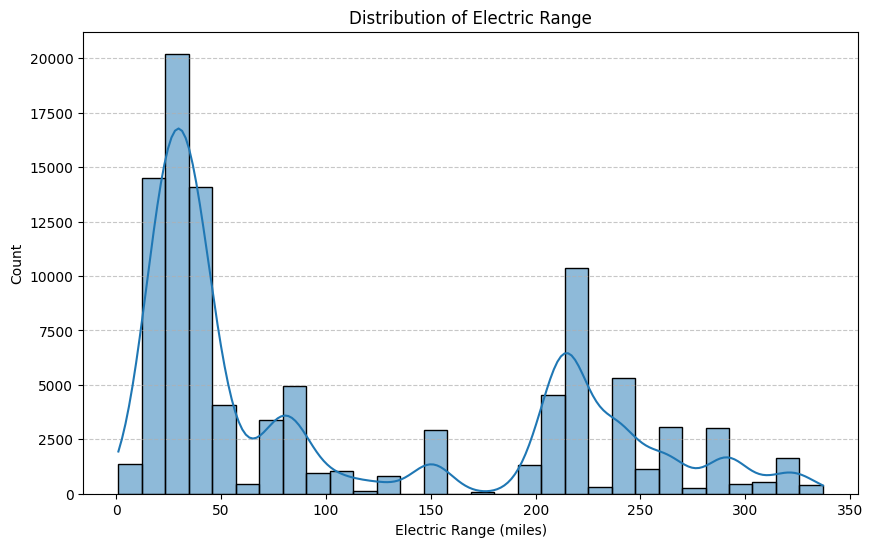

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ----- 3.1 Electric Range — Core Distribution -----
er = df['Electric Range']

print('=== Electric Range — Descriptive Statistics ===')
print(f'  Count  : {er.count():,}')
print(f'  Mean   : {er.mean():.1f} miles')
print(f'  Median : {er.median():.1f} miles')
print(f'  Std Dev: {er.std():.1f} miles')
print(f'  Min    : {er.min():.0f} miles')
print(f'  Max    : {er.max():.0f} miles')
print()

print('=== Percentile Breakdown ===')
pcts = [10, 25, 50, 75, 90, 95, 99]
for p in pcts:
    print(f'  P{p:2d}: {np.percentile(er, p):.1f} miles')
print()

# Skewness and kurtosis using numpy
mean = er.mean()
std  = er.std()
ske = ((er - mean)**3).mean() / std**3
kurt = ((er - mean)**4).mean() / std**4 - 3
print(f'  Skewness : {ske:.3f}  (positive → right-skewed)')
print(f'  Kurtosis : {kurt:.3f}  (excess kurtosis; >0 = heavy tails)')

# Plotting distribution
plt.figure(figsize=(10, 6))
sns.histplot(er, kde=True, bins=30)
plt.title('Distribution of Electric Range')
plt.xlabel('Electric Range (miles)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== Electric Range — Frequency Distribution by Bin ===
        0–30 miles : 26,281
       31–60 miles : 28,292
      61–100 miles :  9,465
     101–150 miles :  3,643
     151–200 miles :  2,605
     201–250 miles : 21,358
     251–300 miles :  7,039
     301–400 miles :  2,592


/tmp/ipykernel_1374/2227368656.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=range_freq.index, y=range_freq.values, palette='viridis')


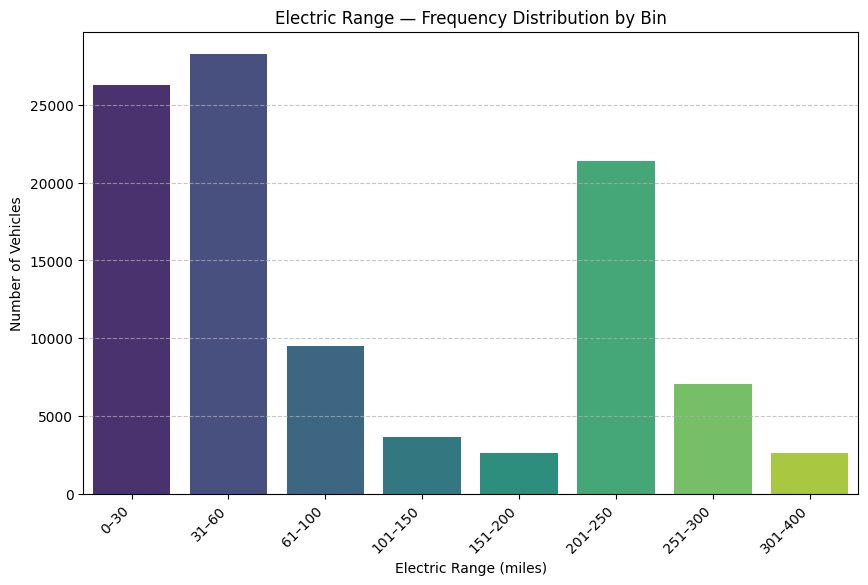

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ----- 3.2 Electric Range — Frequency Binning -----
bins   = [0, 30, 60, 100, 150, 200, 250, 300, 400]
labels = ['0–30', '31–60', '61–100', '101–150', '151–200', '201–250', '251–300', '301–400']

df['Range_Bin'] = pd.cut(df['Electric Range'], bins=bins, labels=labels, right=True)
range_freq = df['Range_Bin'].value_counts().sort_index()

print('=== Electric Range — Frequency Distribution by Bin ===')
for label, count in range_freq.items():
    # Removed bar chart printing logic
    print(f'  {label:>10} miles : {count:>6,}')

# Plotting frequency distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=range_freq.index, y=range_freq.values, palette='viridis')
plt.title('Electric Range — Frequency Distribution by Bin')
plt.xlabel('Electric Range (miles)')
plt.ylabel('Number of Vehicles')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== Model Year — Registration Counts ===
  1999:      2
  2000:      7
  2002:      1
  2003:      1
  2008:     18
  2010:     21
  2011:    573
  2012:  1,366
  2013:  3,914
  2014:  3,172
  2015:  4,393
  2016:  5,068
  2017:  8,397
  2018: 13,956
  2019: 10,772
  2020: 11,970
  2021:  5,027
  2022:  4,873
  2023:  7,473
  2024: 10,723
  2025:  8,006
  2026:  1,542

  Earliest registration year : 1999
  Latest  registration year  : 2026
  Most common year           : 2018


/tmp/ipykernel_1374/3438958008.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yr_counts.index, y=yr_counts.values, palette='crest')


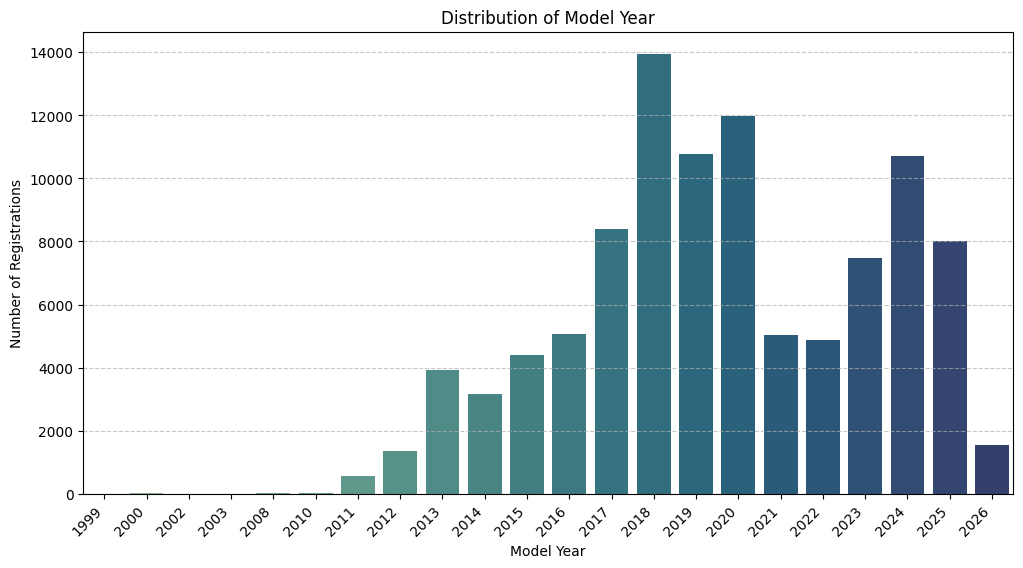

In [ ]:
# ----- 3.3 Model Year Distribution -----
print('=== Model Year — Registration Counts ===')
yr_counts = df['Model Year'].value_counts().sort_index()

for yr, cnt in yr_counts.items():
    # Removed bar chart printing logic
    print(f'  {yr}: {cnt:>6,}')

print()
print(f'  Earliest registration year : {df['Model Year'].min()}')
print(f'  Latest  registration year  : {df['Model Year'].max()}')
print(f'  Most common year           : {df['Model Year'].mode()[0]}')

# Plotting Model Year distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=yr_counts.index, y=yr_counts.values, palette='crest')
plt.title('Distribution of Model Year')
plt.xlabel('Model Year')
plt.ylabel('Number of Registrations')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== Vehicle Age — Descriptive Statistics ===
  Mean   : 6.39 years
  Median : 7.0 years
  Std Dev: 3.56 years
  Min    : 0 years
  Max    : 27 years

=== Vehicle Age — Frequency Counts ===
  Age  0:  1,542
  Age  1:  8,006
  Age  2: 10,723
  Age  3:  7,473
  Age  4:  4,873
  Age  5:  5,027
  Age  6: 11,970
  Age  7: 10,772
  Age  8: 13,956
  Age  9:  8,397
  Age 10:  5,068
  Age 11:  4,393
  Age 12:  3,172
  Age 13:  3,914
  Age 14:  1,366
  Age 15:    573
  Age 16:     21
  Age 18:     18
  Age 23:      1
  Age 24:      1
  Age 26:      7
  Age 27:      2


/tmp/ipykernel_1374/3172889392.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=age_counts.index, y=age_counts.values, palette='rocket')


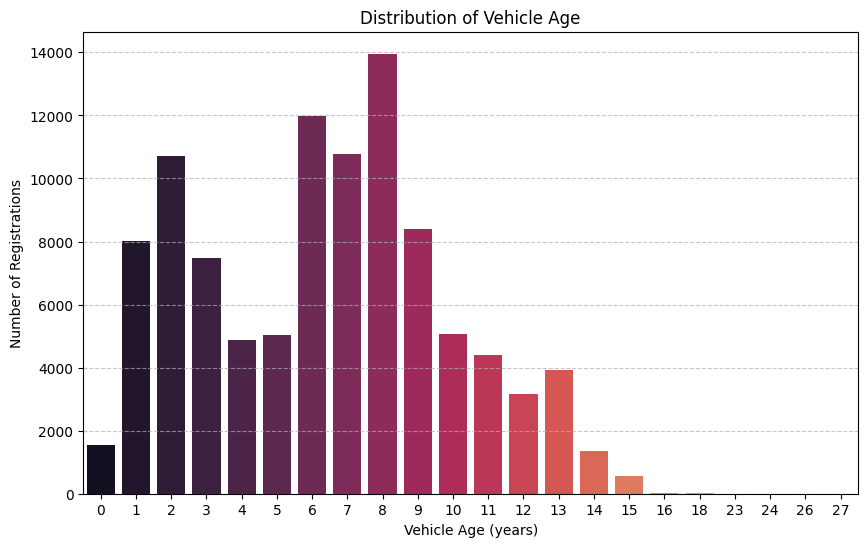

In [ ]:
# ----- 3.4 Vehicle Age Distribution -----
va = df['Vehicle Age']

print('=== Vehicle Age — Descriptive Statistics ===')
print(f'  Mean   : {va.mean():.2f} years')
print(f'  Median : {va.median():.1f} years')
print(f'  Std Dev: {va.std():.2f} years')
print(f'  Min    : {va.min():.0f} years')
print(f'  Max    : {va.max():.0f} years')
print()

print('=== Vehicle Age — Frequency Counts ===')
age_counts = va.value_counts().sort_index()
for age, cnt in age_counts.items():
    # Removed bar chart printing logic
    print(f'  Age {age:>2}: {cnt:>6,}')

# Plotting Vehicle Age distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=age_counts.index, y=age_counts.values, palette='rocket')
plt.title('Distribution of Vehicle Age')
plt.xlabel('Vehicle Age (years)')
plt.ylabel('Number of Registrations')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== Utility Complexity Score — Distribution ===
  Score 1: 25,017  (24.7%)
  Score 2: 66,253  (65.4%)
  Score 3:  9,228  (9.1%)
  Score 4:    777  (0.8%)

  Mean score  : 1.859
  Std Dev     : 0.591


/tmp/ipykernel_1374/4083902602.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ucs.index, y=ucs.values, palette='magma')


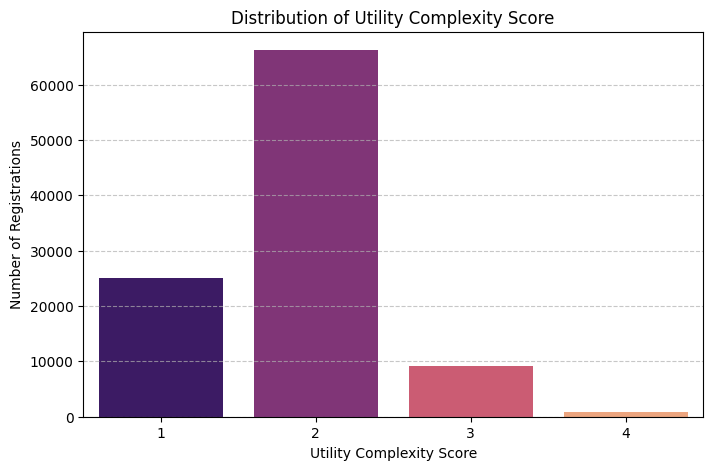

In [ ]:
# ----- 3.5 Utility Complexity Score -----
print('=== Utility Complexity Score — Distribution ===')
ucs = df['Utility_Complexity_Score'].value_counts().sort_index()
for score, cnt in ucs.items():
    pct = cnt / len(df) * 100
    # Removed bar chart printing logic
    print(f'  Score {score}: {cnt:>6,}  ({pct:.1f}%)')

print()
print(f'  Mean score  : {df['Utility_Complexity_Score'].mean():.3f}')
print(f'  Std Dev     : {df['Utility_Complexity_Score'].std():.3f}')

# Plotting Utility Complexity Score distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=ucs.index, y=ucs.values, palette='magma')
plt.title('Distribution of Utility Complexity Score')
plt.xlabel('Utility Complexity Score')
plt.ylabel('Number of Registrations')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

---
## 4. Univariate Analysis — Categorical Columns <a id='4'></a>

=== Electric Vehicle Type ===
  PHEV (Plug-in Hybrid Electric Vehicle (PHEV)) : 55,692  (55.0%)
  BEV (Battery Electric Vehicle (BEV)) : 45,583  (45.0%)


/tmp/ipykernel_1374/438782978.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ev_type.index, y=ev_type.values, palette='mako')


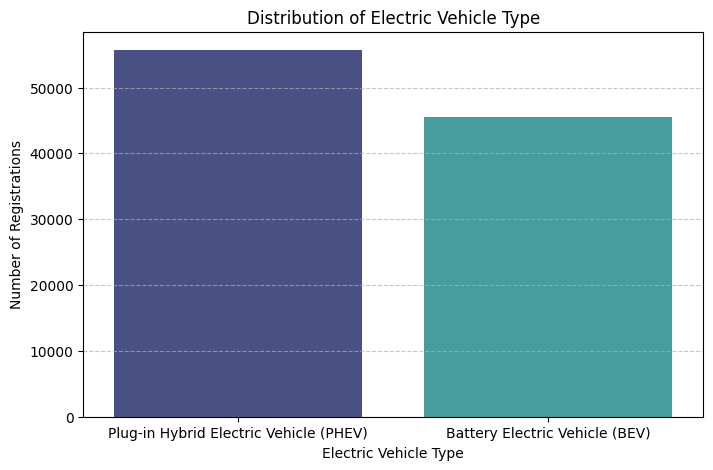

In [ ]:
# ----- 4.1 Electric Vehicle Type -----
print('=== Electric Vehicle Type ===')
ev_type = df['Electric Vehicle Type'].value_counts()
for t, cnt in ev_type.items():
    short = 'BEV' if 'Battery' in t else 'PHEV'
    pct   = cnt / len(df) * 100
    print(f'  {short} ({t}) : {cnt:,}  ({pct:.1f}%)')

# Plotting Electric Vehicle Type distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=ev_type.index, y=ev_type.values, palette='mako')
plt.title('Distribution of Electric Vehicle Type')
plt.xlabel('Electric Vehicle Type')
plt.ylabel('Number of Registrations')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== Top 15 Makes by Registration Count ===
  TESLA          : 24,182  (23.9%)
  CHEVROLET      :  9,848  ( 9.7%)
  TOYOTA         :  9,750  ( 9.6%)
  NISSAN         :  9,631  ( 9.5%)
  BMW            :  7,048  ( 7.0%)
  JEEP           :  6,568  ( 6.5%)
  KIA            :  5,725  ( 5.7%)
  VOLVO          :  4,829  ( 4.8%)
  FORD           :  4,106  ( 4.1%)
  CHRYSLER       :  3,684  ( 3.6%)
  AUDI           :  2,870  ( 2.8%)
  HYUNDAI        :  1,619  ( 1.6%)
  MAZDA          :  1,523  ( 1.5%)
  MERCEDES-BENZ  :  1,302  ( 1.3%)
  MITSUBISHI     :  1,283  ( 1.3%)

  Total unique makes: 36
  Top 5 makes cover : 59.7% of fleet


/tmp/ipykernel_1374/3517944512.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_makes.index, y=top_makes.values, palette='viridis')


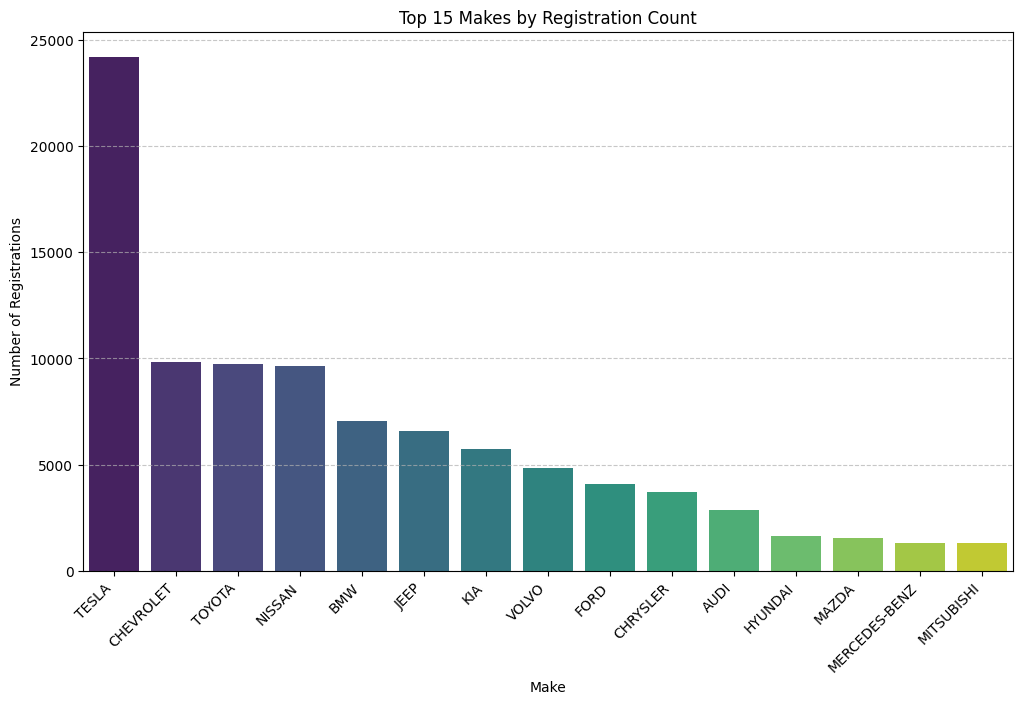

In [ ]:
# ----- 4.2 Top 15 Makes -----
print('=== Top 15 Makes by Registration Count ===')
top_makes = df['Make'].value_counts().head(15)

for make, cnt in top_makes.items():
    pct = cnt / len(df) * 100
    # Removed bar chart printing logic
    print(f'  {make:<15}: {cnt:>6,}  ({pct:4.1f}%)')

print()
print(f'  Total unique makes: {df['Make'].nunique()}')
print(f'  Top 5 makes cover : {top_makes.head(5).sum() / len(df) * 100:.1f}% of fleet')

# Plotting Top 15 Makes
plt.figure(figsize=(12, 7))
sns.barplot(x=top_makes.index, y=top_makes.values, palette='viridis')
plt.title('Top 15 Makes by Registration Count')
plt.xlabel('Make')
plt.ylabel('Number of Registrations')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== Tesla Models (24,182 registrations) ===
  MODEL 3     : 13,199  (54.6%)
  MODEL S     :  5,470  (22.6%)
  MODEL X     :  3,143  (13.0%)
  MODEL Y     :  2,325  (9.6%)
  ROADSTER    :     45  (0.2%)


/tmp/ipykernel_1374/1579996207.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tesla_models.index, y=tesla_models.values, palette='cubehelix')


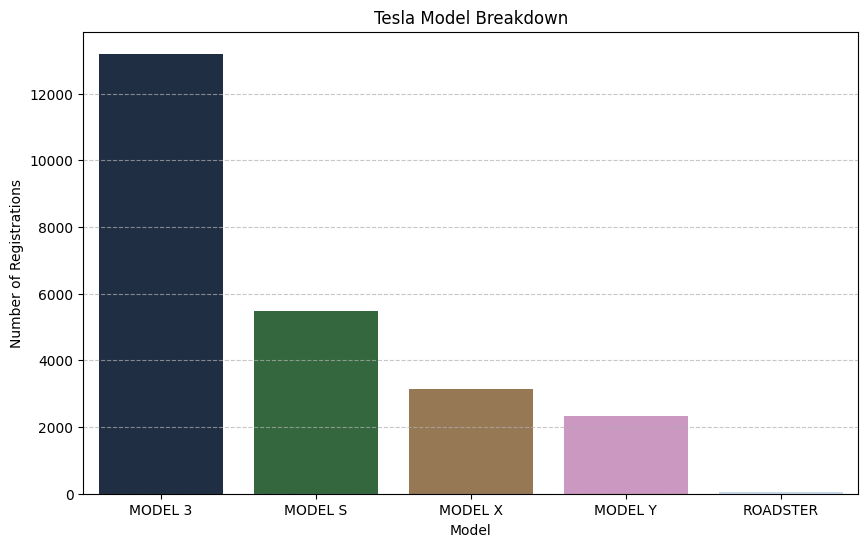

In [ ]:
# ----- 4.3 Tesla Model Breakdown -----
tesla = df[df['Make'] == 'TESLA']
print(f'=== Tesla Models ({len(tesla):,} registrations) ===')

tesla_models = tesla['Model'].value_counts()
for model, cnt in tesla_models.items():
    pct = cnt / len(tesla) * 100
    print(f'  {model:<12}: {cnt:>6,}  ({pct:.1f}%)')

# Plotting Tesla Model Breakdown
plt.figure(figsize=(10, 6))
sns.barplot(x=tesla_models.index, y=tesla_models.values, palette='cubehelix')
plt.title('Tesla Model Breakdown')
plt.xlabel('Model')
plt.ylabel('Number of Registrations')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== Market Segment ===
  Mass Market : 64,810  (64.0%)
  Luxury      : 36,465  (36.0%)


/tmp/ipykernel_1374/1201564224.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=market_seg.index, y=market_seg.values, palette='winter')


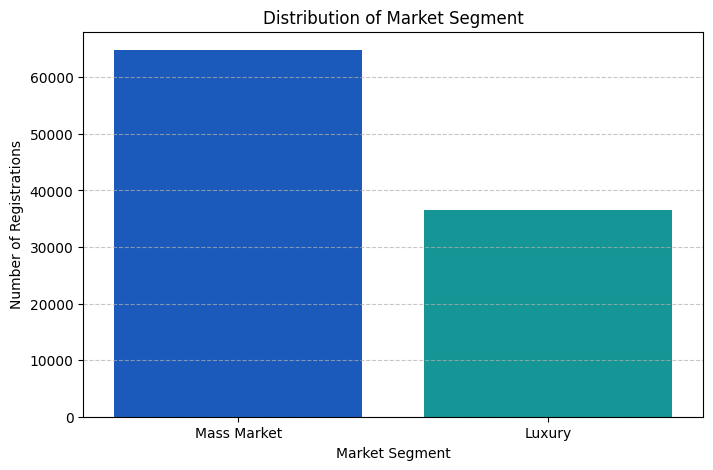

In [ ]:
# ----- 4.4 Market Segment -----
print('=== Market Segment ===')
market_seg = df['Market_Segment'].value_counts()
for seg, cnt in market_seg.items():
    pct = cnt / len(df) * 100
    print(f'  {seg:<12}: {cnt:>6,}  ({pct:.1f}%)')

# Plotting Market Segment distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=market_seg.index, y=market_seg.values, palette='winter')
plt.title('Distribution of Market Segment')
plt.xlabel('Market Segment')
plt.ylabel('Number of Registrations')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== Adoption Wave ===
  Early         : 13,468  (13.3%)
  Growth        : 50,163  (49.5%)
  Mass Adoption : 37,644  (37.2%)


/tmp/ipykernel_1374/1661821925.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=adoption_wave.index, y=adoption_wave.values, palette='autumn')


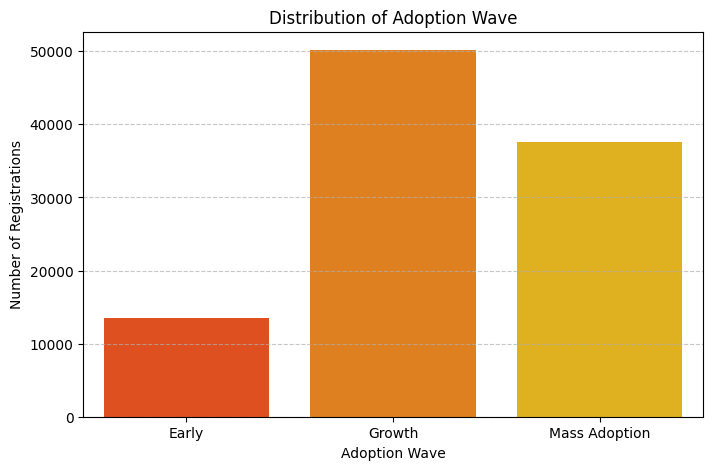

In [ ]:
# ----- 4.5 Adoption Wave -----
print('=== Adoption Wave ===')
wave_order = ['Early', 'Growth', 'Mass Adoption']
adoption_wave = df['Adoption_Wave'].value_counts().reindex(wave_order)

for wave in wave_order:
    cnt = (df['Adoption_Wave'] == wave).sum()
    pct = cnt / len(df) * 100
    # Removed bar chart printing logic
    print(f'  {wave:<14}: {cnt:>6,}  ({pct:.1f}%)')

# Plotting Adoption Wave distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=adoption_wave.index, y=adoption_wave.values, palette='autumn')
plt.title('Distribution of Adoption Wave')
plt.xlabel('Adoption Wave')
plt.ylabel('Number of Registrations')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== Range Category ===
  Urban Commuter    : 64,038  (63.2%)
  Regional Traveler : 27,606  (27.3%)
  Long Range        :  9,631  (9.5%)


/tmp/ipykernel_1374/255848921.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=range_cat.index, y=range_cat.values, palette='cool')


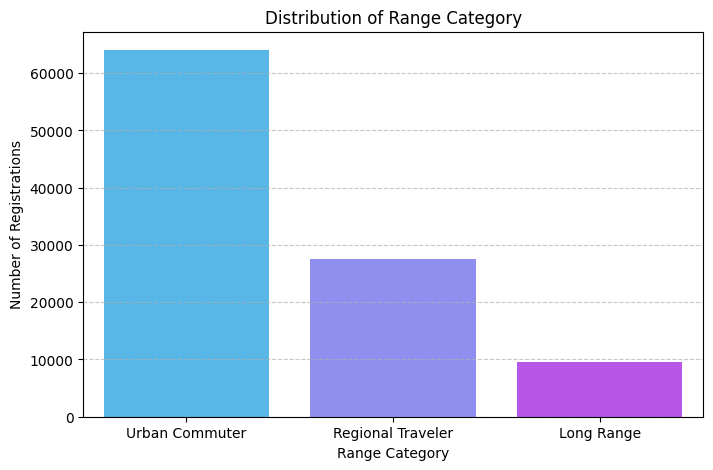

In [ ]:
# ----- 4.6 Range Category -----
print('=== Range Category ===')
range_cat = df['Range_Category'].value_counts()
for cat, cnt in range_cat.items():
    pct = cnt / len(df) * 100
    # Removed bar chart printing logic
    print(f'  {cat:<18}: {cnt:>6,}  ({pct:.1f}%)')

# Plotting Range Category distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=range_cat.index, y=range_cat.values, palette='cool')
plt.title('Distribution of Range Category')
plt.xlabel('Range Category')
plt.ylabel('Number of Registrations')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== CAFV Status ===
  Eligible                 : 77,118  (76.1%)
  Unknown/Not Eligible     : 24,157  (23.9%)


/tmp/ipykernel_1374/3976091028.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cafv_status.index, y=cafv_status.values, palette='spring')


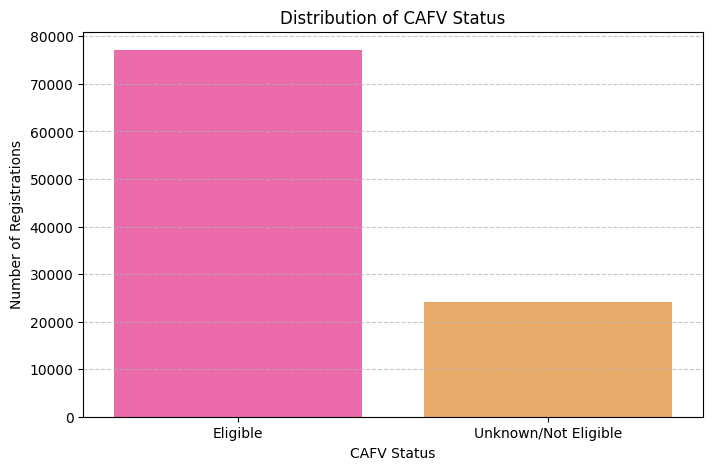

In [ ]:
# ----- 4.7 CAFV Eligibility -----
print('=== CAFV Status ===')
cafv_status = df['CAFV_Status'].value_counts()
for status, cnt in cafv_status.items():
    pct = cnt / len(df) * 100
    print(f'  {status:<25}: {cnt:>6,}  ({pct:.1f}%)')

# Plotting CAFV Status distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=cafv_status.index, y=cafv_status.values, palette='spring')
plt.title('Distribution of CAFV Status')
plt.xlabel('CAFV Status')
plt.ylabel('Number of Registrations')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

---
## 5. Bivariate & Group Analysis <a id='5'></a>

=== Average Electric Range by EV Type ===
                                        Count   Mean  Median   Std   Min    Max
Electric Vehicle Type                                                          
Battery Electric Vehicle (BEV)          45583 199.95  215.00 72.03 29.00 337.00
Plug-in Hybrid Electric Vehicle (PHEV)  55692  31.76   32.00 13.94  1.00 153.00


/tmp/ipykernel_1374/440919104.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Electric Vehicle Type', y='Electric Range', data=df, palette='viridis')


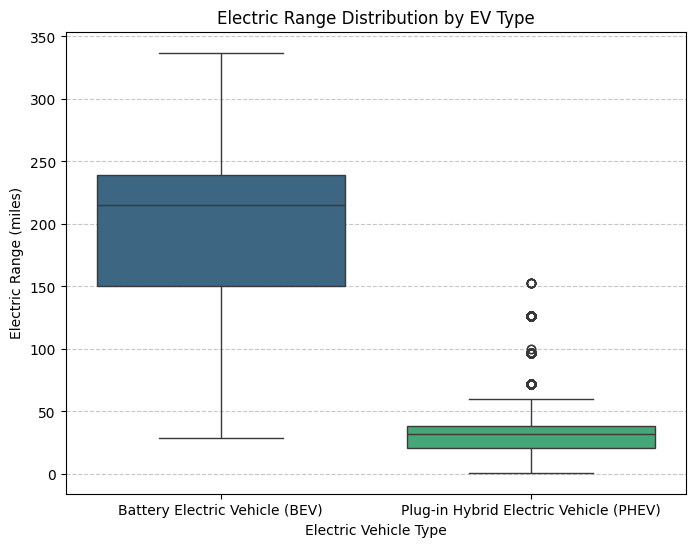

In [ ]:
# ----- 5.1 Electric Range by Vehicle Type -----
print('=== Average Electric Range by EV Type ===')
range_by_type = df.groupby('Electric Vehicle Type')['Electric Range'].agg(
    Count='count', Mean='mean', Median='median', Std='std', Min='min', Max='max'
).round(2)
print(range_by_type.to_string())

# Plotting Electric Range by EV Type
plt.figure(figsize=(8, 6))
sns.boxplot(x='Electric Vehicle Type', y='Electric Range', data=df, palette='viridis')
plt.title('Electric Range Distribution by EV Type')
plt.xlabel('Electric Vehicle Type')
plt.ylabel('Electric Range (miles)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== Electric Range Stats — Top 10 Makes ===
           Count   Mean  Median   Std
Make                                 
TESLA      24182 241.50  220.00 39.30
CHEVROLET   9848 151.70  238.00 99.10
NISSAN      9631 106.20   84.00 36.50
KIA         5725  68.80   34.00 73.70
BMW         7048  44.40   30.00 32.00
TOYOTA      9750  33.70   42.00 12.70
CHRYSLER    3684  32.20   32.00  0.40
VOLVO       4829  27.90   32.00  8.40
FORD        4106  26.60   19.00 14.60
JEEP        6568  22.30   21.00  1.80


/tmp/ipykernel_1374/2368679400.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=range_by_make.index, y=range_by_make['Mean'], palette='cubehelix')


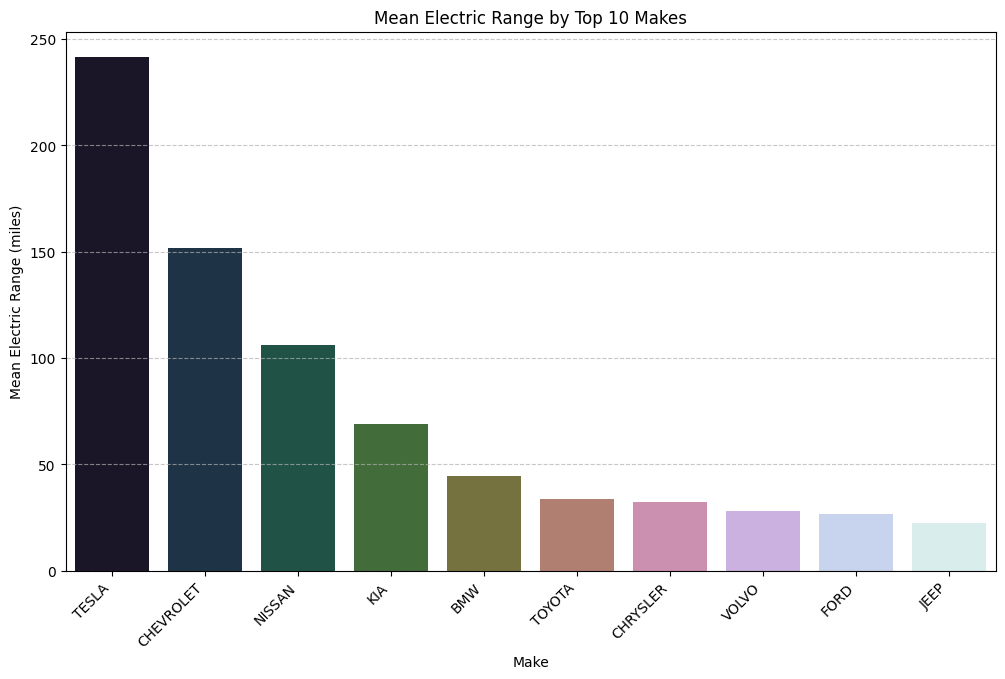

In [ ]:
# ----- 5.2 Electric Range by Top 10 Makes -----
top10_makes = df['Make'].value_counts().head(10).index

print('=== Electric Range Stats — Top 10 Makes ===')
range_by_make = (
    df[df['Make'].isin(top10_makes)]
    .groupby('Make')['Electric Range']
    .agg(Count='count', Mean='mean', Median='median', Std='std')
    .round(1)
    .sort_values('Mean', ascending=False)
)
print(range_by_make.to_string())

# Plotting Mean Electric Range by Top 10 Makes
plt.figure(figsize=(12, 7))
sns.barplot(x=range_by_make.index, y=range_by_make['Mean'], palette='cubehelix')
plt.title('Mean Electric Range by Top 10 Makes')
plt.xlabel('Make')
plt.ylabel('Mean Electric Range (miles)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== Adoption Wave × EV Type — Counts ===
Electric Vehicle Type  Battery Electric Vehicle (BEV)  Plug-in Hybrid Electric Vehicle (PHEV)     All
Adoption_Wave                                                                                        
Early                                            8284                                    5184   13468
Growth                                          36499                                   13664   50163
Mass Adoption                                     800                                   36844   37644
All                                             45583                                   55692  101275

=== Adoption Wave × EV Type — Row % ===
Electric Vehicle Type  Battery Electric Vehicle (BEV)  Plug-in Hybrid Electric Vehicle (PHEV)
Adoption_Wave                                                                                
Early                                           61.50                                   38.50
Growth                  

<Figure size 1000x600 with 0 Axes>

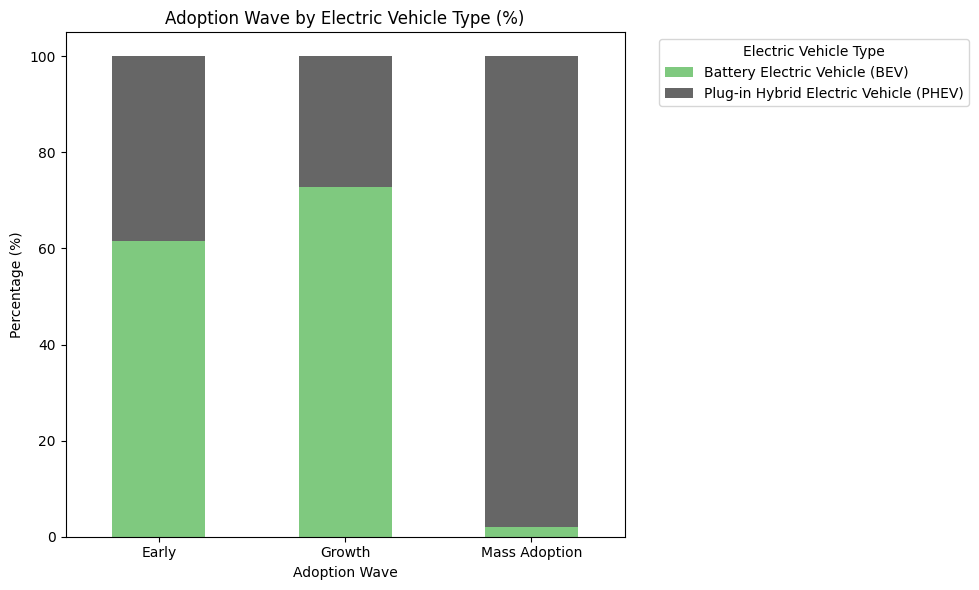

In [ ]:
# ----- 5.3 Adoption Wave × EV Type Cross-tab -----
print('=== Adoption Wave × EV Type — Counts ===')
ct = pd.crosstab(df['Adoption_Wave'], df['Electric Vehicle Type'], margins=True)
print(ct.to_string())
print()

print('=== Adoption Wave × EV Type — Row % ===')
ct_pct = pd.crosstab(df['Adoption_Wave'], df['Electric Vehicle Type'], normalize='index').mul(100).round(1)
print(ct_pct.to_string())

# Plotting Adoption Wave × EV Type — Row %
ct_pct.drop('All', errors='ignore', inplace=True) # Drop 'All' row if it exists for plotting
plt.figure(figsize=(10, 6))
ct_pct.plot(kind='bar', stacked=True, colormap='Accent', figsize=(10, 6))
plt.title('Adoption Wave by Electric Vehicle Type (%)')
plt.xlabel('Adoption Wave')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Electric Vehicle Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

=== Market Segment × EV Type — Counts ===
Electric Vehicle Type  Battery Electric Vehicle (BEV)  Plug-in Hybrid Electric Vehicle (PHEV)     All
Market_Segment                                                                                       
Luxury                                          26002                                   10463   36465
Mass Market                                     19581                                   45229   64810
All                                             45583                                   55692  101275

=== Market Segment × EV Type — Row % ===
Electric Vehicle Type  Battery Electric Vehicle (BEV)  Plug-in Hybrid Electric Vehicle (PHEV)
Market_Segment                                                                               
Luxury                                          71.30                                   28.70
Mass Market                                     30.20                                   69.80


<Figure size 1000x600 with 0 Axes>

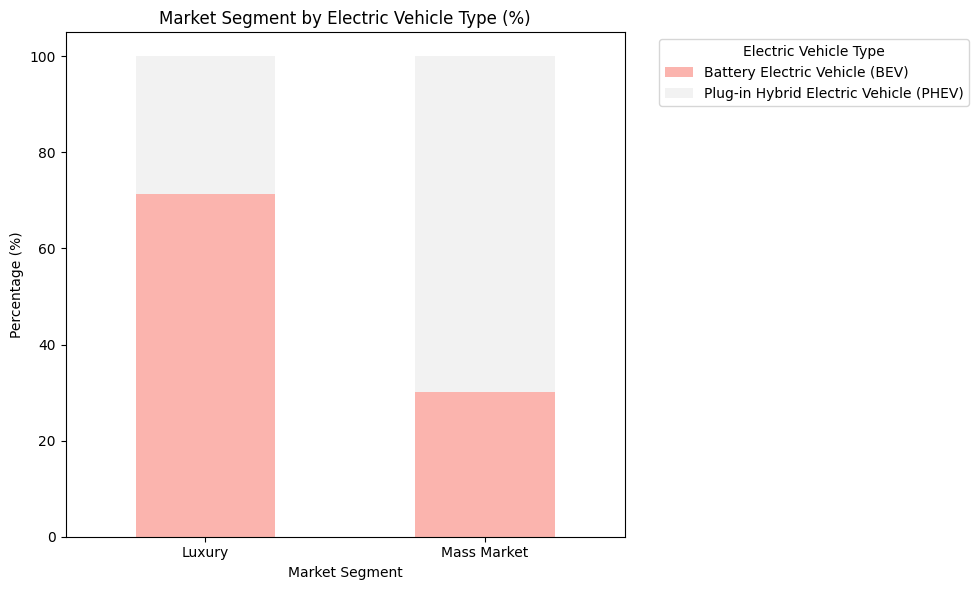

In [ ]:
# ----- 5.4 Market Segment × EV Type -----
print('=== Market Segment × EV Type — Counts ===')
ct2 = pd.crosstab(df['Market_Segment'], df['Electric Vehicle Type'], margins=True)
print(ct2.to_string())
print()

print('=== Market Segment × EV Type — Row % ===')
ct2_pct = pd.crosstab(df['Market_Segment'], df['Electric Vehicle Type'], normalize='index').mul(100).round(1)
print(ct2_pct.to_string())

# Plotting Market Segment × EV Type — Row %
ct2_pct.drop('All', errors='ignore', inplace=True) # Drop 'All' row if it exists for plotting
plt.figure(figsize=(10, 6))
ct2_pct.plot(kind='bar', stacked=True, colormap='Pastel1', figsize=(10, 6))
plt.title('Market Segment by Electric Vehicle Type (%)')
plt.xlabel('Market Segment')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Electric Vehicle Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

=== CAFV Eligibility × EV Type ===
Electric Vehicle Type  Battery Electric Vehicle (BEV)  Plug-in Hybrid Electric Vehicle (PHEV)
CAFV_Status                                                                                  
Eligible                                        59.10                                   40.90
Unknown/Not Eligible                             0.00                                  100.00


<Figure size 1000x600 with 0 Axes>

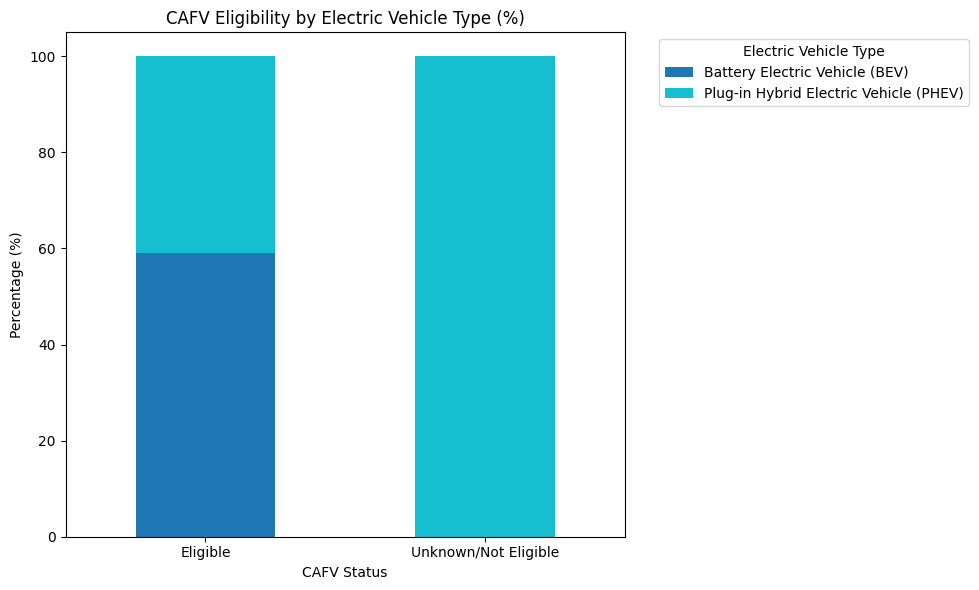

In [ ]:
# ----- 5.5 CAFV Eligibility × EV Type -----
print('=== CAFV Eligibility × EV Type ===')
ct3 = pd.crosstab(df['CAFV_Status'], df['Electric Vehicle Type'], normalize='index').mul(100).round(1)
print(ct3.to_string())

# Plotting CAFV Eligibility × EV Type
plt.figure(figsize=(10, 6))
ct3.plot(kind='bar', stacked=True, colormap='tab10', figsize=(10, 6))
plt.title('CAFV Eligibility by Electric Vehicle Type (%)')
plt.xlabel('CAFV Status')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Electric Vehicle Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Pearson Correlation — Vehicle Age vs Electric Range: 0.2676

Interpretation:
  Weak correlation

=== Correlation Matrix (numeric cols) ===
                          Model Year  Electric Range  Vehicle Age  Utility_Complexity_Score  Latitude  Longitude
Model Year                      1.00           -0.27        -1.00                      0.01     -0.03       0.02
Electric Range                 -0.27            1.00         0.27                     -0.02      0.02      -0.01
Vehicle Age                    -1.00            0.27         1.00                     -0.01      0.03      -0.02
Utility_Complexity_Score        0.01           -0.02        -0.01                      1.00     -0.07      -0.04
Latitude                       -0.03            0.02         0.03                     -0.07      1.00      -0.43
Longitude                       0.02           -0.01        -0.02                     -0.04     -0.43       1.00


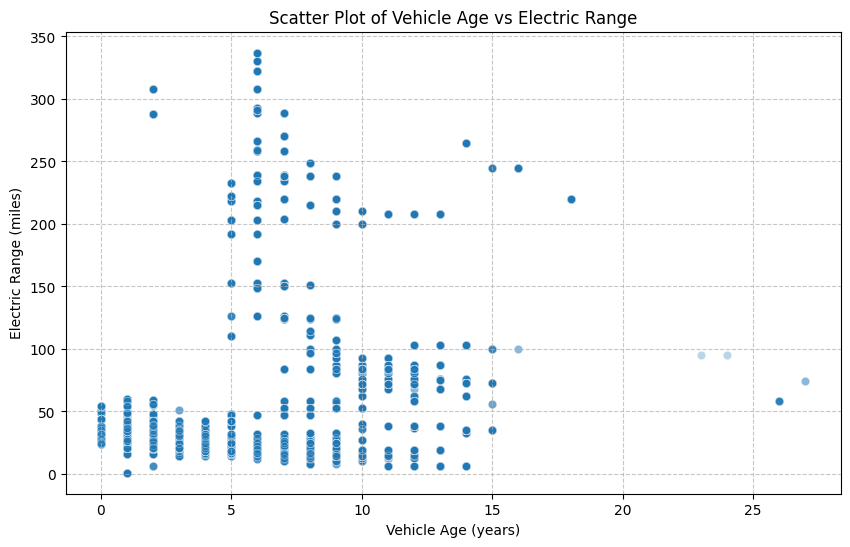

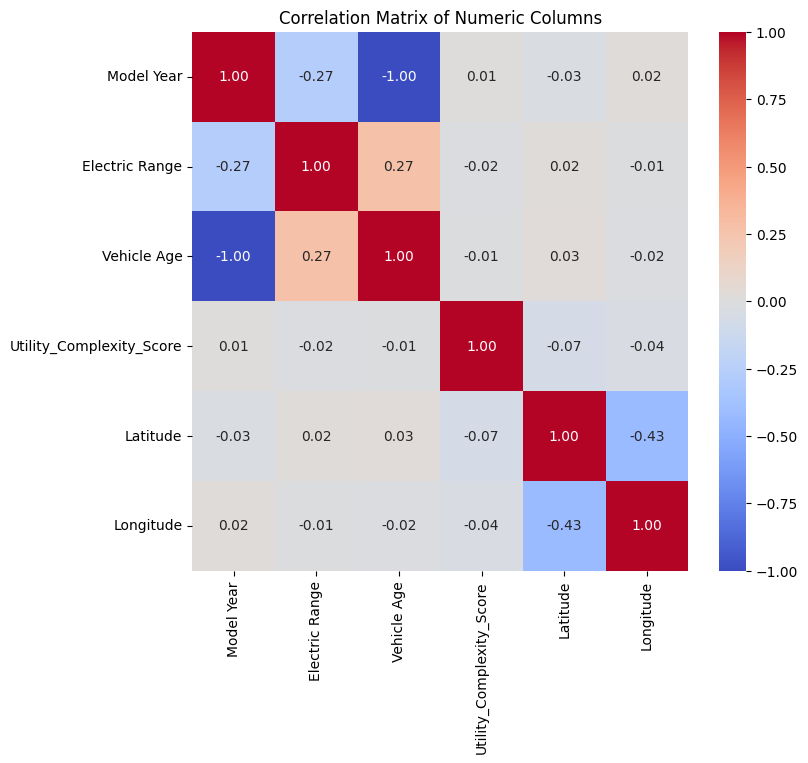

In [ ]:
# ----- 5.6 Vehicle Age vs Electric Range — Correlation -----
# Using numpy corrcoef
corr_age_range = np.corrcoef(df['Vehicle Age'], df['Electric Range'])[0, 1]
print(f'Pearson Correlation — Vehicle Age vs Electric Range: {corr_age_range:.4f}')
print()

print('Interpretation:')
if abs(corr_age_range) < 0.1:
    print('  Negligible correlation')
elif abs(corr_age_range) < 0.3:
    print('  Weak correlation')
elif abs(corr_age_range) < 0.5:
    print('  Moderate correlation')
else:
    print('  Strong correlation')

# Correlation matrix for all numeric cols
num_df = df[['Model Year', 'Electric Range', 'Vehicle Age', 'Utility_Complexity_Score', 'Latitude', 'Longitude']]
print()
print('=== Correlation Matrix (numeric cols) ===')
corr_matrix = num_df.corr().round(3)
print(corr_matrix.to_string())

# Plotting scatter plot for Vehicle Age vs Electric Range
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Vehicle Age', y='Electric Range', data=df, alpha=0.3)
plt.title('Scatter Plot of Vehicle Age vs Electric Range')
plt.xlabel('Vehicle Age (years)')
plt.ylabel('Electric Range (miles)')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

# Plotting heatmap for correlation matrix
plt.figure(figsize=(8, 7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Columns')
plt.show()

=== Range Stats by Range_Category ===
                   Count    Min   Mean    Max
Range_Category                               
Long Range          9631 258.00 288.20 337.00
Regional Traveler  27606 103.00 205.60 249.00
Urban Commuter     64038   1.00  38.00 100.00


/tmp/ipykernel_1374/3269650271.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Range_Category', y='Electric Range', data=df, palette='Spectral')


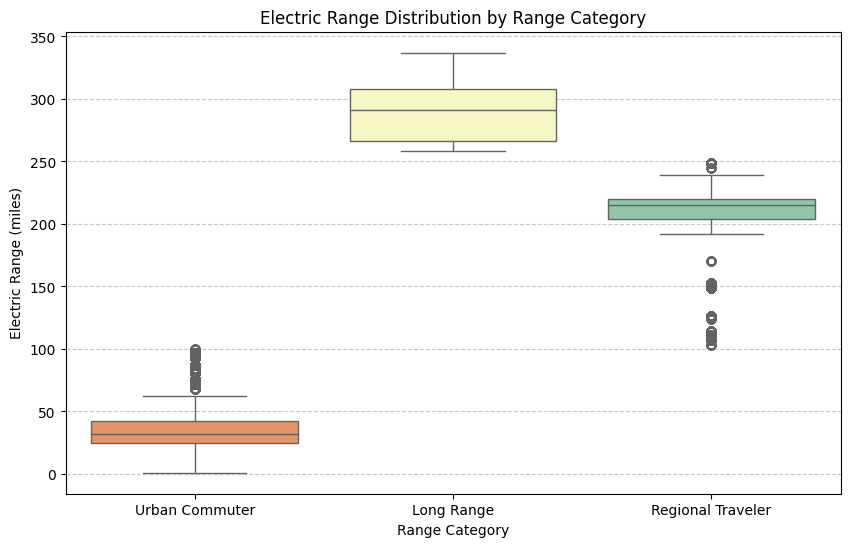

In [ ]:
# ----- 5.7 Electric Range by Range Category (sanity check) -----
print('=== Range Stats by Range_Category ===')
print(
    df.groupby('Range_Category')['Electric Range']
    .agg(Count='count', Min='min', Mean='mean', Max='max')
    .round(1)
    .to_string()
)

# Plotting Electric Range by Range Category
plt.figure(figsize=(10, 6))
sns.boxplot(x='Range_Category', y='Electric Range', data=df, palette='Spectral')
plt.title('Electric Range Distribution by Range Category')
plt.xlabel('Range Category')
plt.ylabel('Electric Range (miles)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== Model Year × EV Type — Row % ===
Electric Vehicle Type  Battery Electric Vehicle (BEV)  Plug-in Hybrid Electric Vehicle (PHEV)
Model Year                                                                                   
2011                                            90.10                                    9.90
2012                                            44.40                                   55.60
2013                                            61.90                                   38.10
2014                                            48.30                                   51.70
2015                                            71.90                                   28.10
2016                                            67.50                                   32.50
2017                                            53.60                                   46.40
2018                                            69.80                                   30.20
2019                   

<Figure size 1200x600 with 0 Axes>

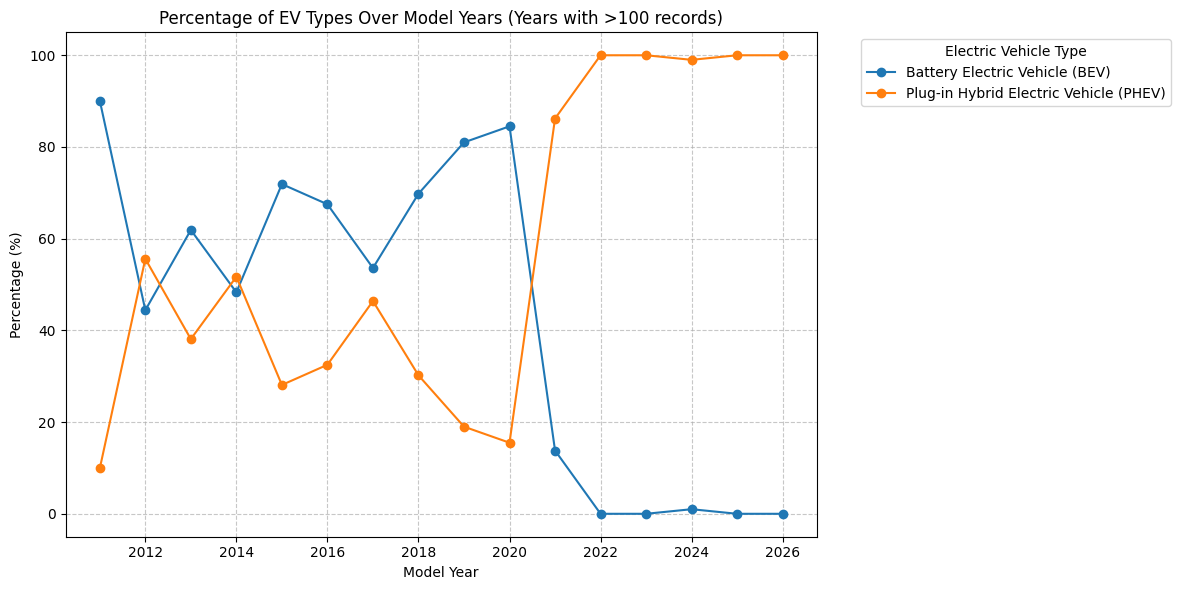

In [ ]:
# ----- 5.8 Model Year × EV Type — how BEV vs PHEV share changes over time -----
print('=== Model Year × EV Type — Row % ===')
yr_type = pd.crosstab(df['Model Year'], df['Electric Vehicle Type'], normalize='index').mul(100).round(1)
# Show only years with > 100 records for clean signal
yr_counts_filter = df['Model Year'].value_counts()
valid_yrs = yr_counts_filter[yr_counts_filter >= 100].index
print(yr_type.loc[yr_type.index.isin(valid_yrs)].to_string())

# Plotting Model Year × EV Type — Row %
plt.figure(figsize=(12, 6))
yr_type.loc[yr_type.index.isin(valid_yrs)].plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Percentage of EV Types Over Model Years (Years with >100 records)')
plt.xlabel('Model Year')
plt.ylabel('Percentage (%)')
plt.grid(linestyle='--', alpha=0.7)
plt.legend(title='Electric Vehicle Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

---
## 6. Trend Analysis — Model Year <a id='6'></a>

=== Yearly Registration Trend ===
            Registrations  YoY_Growth_%
Model Year                             
2011                  573       2628.60
2012                 1366        138.40
2013                 3914        186.50
2014                 3172        -19.00
2015                 4393         38.50
2016                 5068         15.40
2017                 8397         65.70
2018                13956         66.20
2019                10772        -22.80
2020                11970         11.10
2021                 5027        -58.00
2022                 4873         -3.10
2023                 7473         53.40
2024                10723         43.50
2025                 8006        -25.30
2026                 1542        -80.70

Peak year (registrations): 2018 — 13,956 units
Avg YoY growth (2012–2024): 39.7%


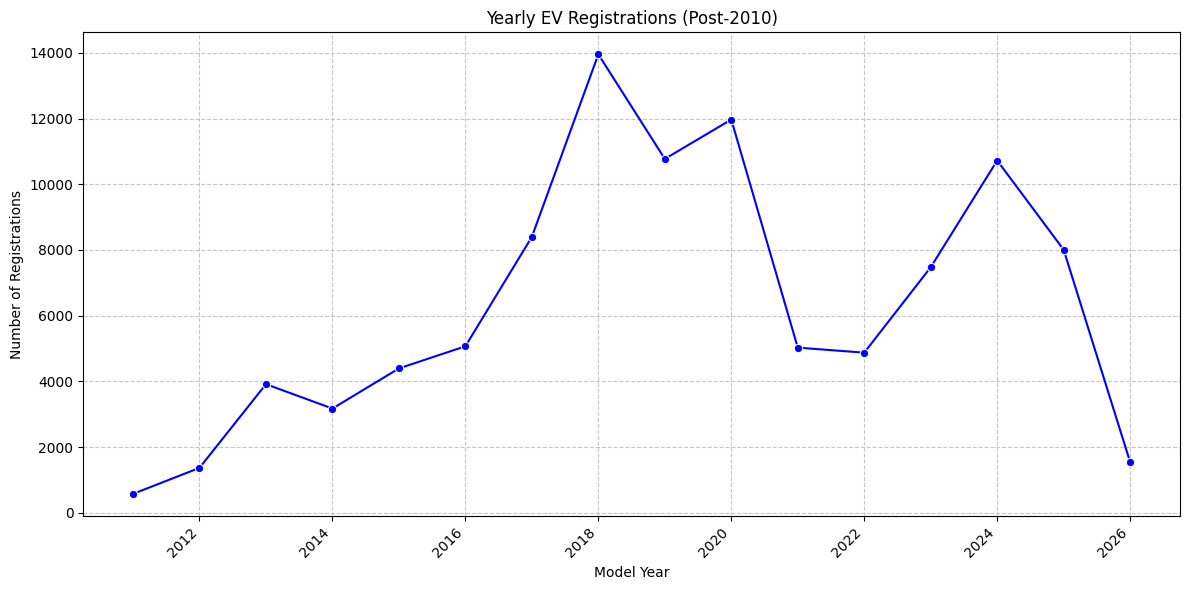

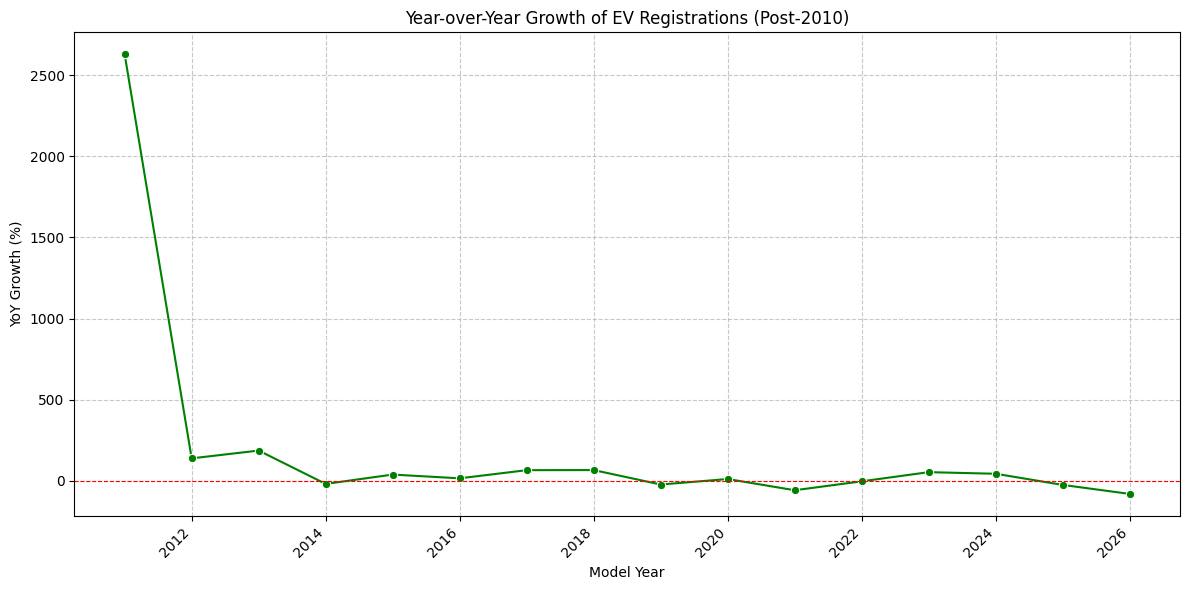

In [ ]:
# ----- 6.1 Yearly Registration Count & YoY Growth -----
yr_reg = df['Model Year'].value_counts().sort_index()

# YoY growth rate
yr_df = pd.DataFrame({'Registrations': yr_reg})
yr_df['YoY_Growth_%'] = yr_df['Registrations'].pct_change().mul(100).round(1)

# Filter to years with meaningful volume (post-2010)
yr_df_filtered = yr_df[yr_df.index >= 2011]

print('=== Yearly Registration Trend ===')
print(yr_df_filtered.to_string())
print()
print(f'Peak year (registrations): {yr_df_filtered['Registrations'].idxmax()} — {yr_df_filtered['Registrations'].max():,} units')
print(f'Avg YoY growth (2012–2024): {yr_df_filtered.loc[2012:2024, 'YoY_Growth_%'].mean():.1f}%')

# Plotting Yearly Registration Count
plt.figure(figsize=(12, 6))
sns.lineplot(x=yr_df_filtered.index, y=yr_df_filtered['Registrations'], marker='o', color='blue')
plt.title('Yearly EV Registrations (Post-2010)')
plt.xlabel('Model Year')
plt.ylabel('Number of Registrations')
plt.grid(linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plotting YoY Growth %
plt.figure(figsize=(12, 6))
sns.lineplot(x=yr_df_filtered.index, y=yr_df_filtered['YoY_Growth_%'], marker='o', color='green')
plt.title('Year-over-Year Growth of EV Registrations (Post-2010)')
plt.xlabel('Model Year')
plt.ylabel('YoY Growth (%)')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.grid(linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

=== Average Electric Range by Model Year (≥ 2013) ===
            Count  Mean_Range  Median_Range
Model Year                                 
2013         3914       77.30         75.00
2014         3172       78.00         72.00
2015         4393       96.10         84.00
2016         5068      101.10         84.00
2017         8397      117.10         97.00
2018        13956      157.20        215.00
2019        10772      176.10        220.00
2020        11970      238.20        266.00
2021         5027       52.00         29.00
2022         4873       28.90         30.00
2023         7473       30.60         32.00
2024        10723       34.60         32.00
2025         8006       35.20         35.00
2026         1542       37.40         38.00

Mean range in 2013 : 77.3 miles
Mean range in 2024 : 34.6 miles
Improvement        : -55.2%


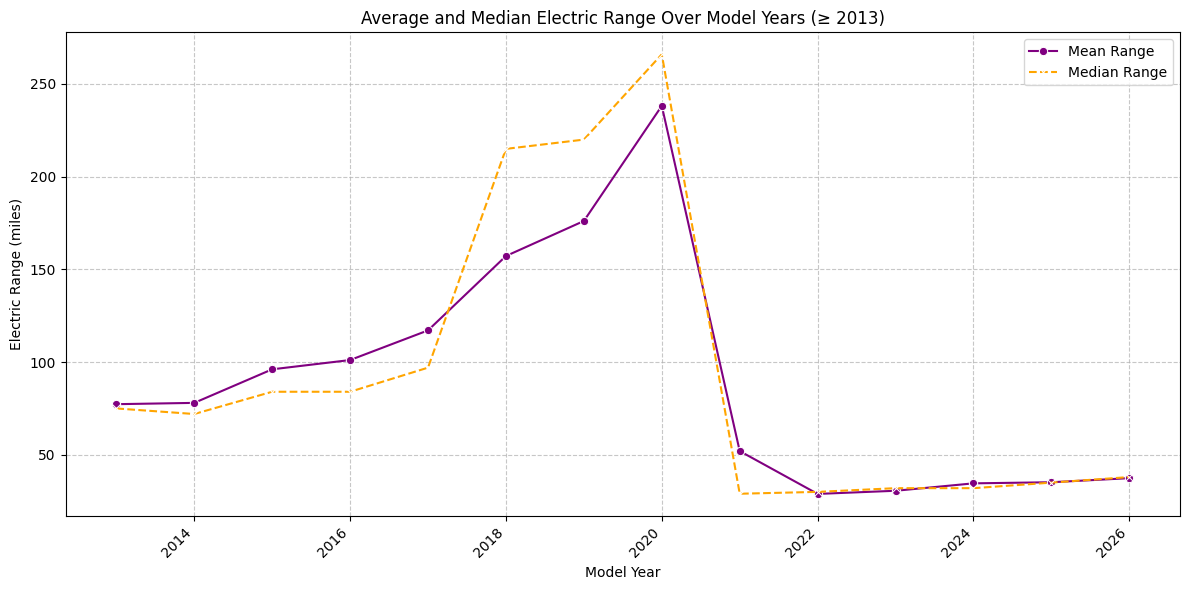

In [ ]:
# ----- 6.2 Average Electric Range Over Time -----
print('=== Average Electric Range by Model Year (≥ 2013) ===')
range_trend = (
    df[df['Model Year'] >= 2013]
    .groupby('Model Year')['Electric Range']
    .agg(Count='count', Mean_Range='mean', Median_Range='median')
    .round(1)
)
print(range_trend.to_string())

# Overall range improvement
r2013 = range_trend.loc[2013, 'Mean_Range']
r2024 = range_trend.loc[2024, 'Mean_Range']
print()
print(f'Mean range in 2013 : {r2013:.1f} miles')
print(f'Mean range in 2024 : {r2024:.1f} miles')
print(f'Improvement        : {((r2024 - r2013) / r2013 * 100):.1f}%')

# Plotting Average Electric Range Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(x=range_trend.index, y=range_trend['Mean_Range'], marker='o', label='Mean Range', color='purple')
sns.lineplot(x=range_trend.index, y=range_trend['Median_Range'], marker='x', label='Median Range', color='orange', linestyle='--')
plt.title('Average and Median Electric Range Over Model Years (≥ 2013)')
plt.xlabel('Model Year')
plt.ylabel('Electric Range (miles)')
plt.grid(linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

=== BEV Count by Model Year ===
              BEV   PHEV  Total  BEV_%
Model Year                            
2011          516     57    573  90.10
2012          607    759   1366  44.40
2013         2421   1493   3914  61.90
2014         1532   1640   3172  48.30
2015         3160   1233   4393  71.90
2016         3420   1648   5068  67.50
2017         4498   3899   8397  53.60
2018         9740   4216  13956  69.80
2019         8726   2046  10772  81.00
2020        10115   1855  11970  84.50
2021          696   4331   5027  13.80
2024          104  10619  10723   1.00
2022            0   4873   4873   0.00
2023            0   7473   7473   0.00
2025            0   8006   8006   0.00
2026            0   1542   1542   0.00


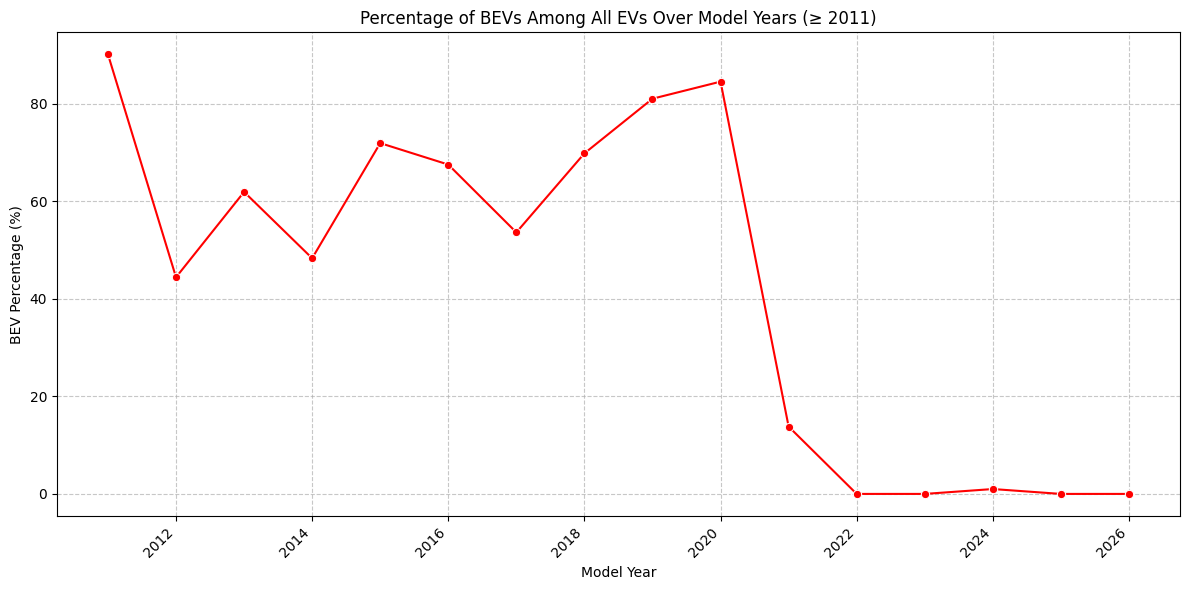

In [ ]:
# ----- 6.3 BEV Growth Over Time -----
print('=== BEV Count by Model Year ===')
bev = df[df['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)']
phev = df[df['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)']

bev_yr = bev['Model Year'].value_counts().sort_index().rename('BEV')
phev_yr = phev['Model Year'].value_counts().sort_index().rename('PHEV')

ev_type_yr = pd.concat([bev_yr, phev_yr], axis=1).fillna(0).astype(int)
ev_type_yr = ev_type_yr[ev_type_yr.index >= 2011]
ev_type_yr['Total'] = ev_type_yr['BEV'] + ev_type_yr['PHEV']
ev_type_yr['BEV_%'] = (ev_type_yr['BEV'] / ev_type_yr['Total'] * 100).round(1)

print(ev_type_yr.to_string())

# Plotting BEV % Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(x=ev_type_yr.index, y=ev_type_yr['BEV_%'], marker='o', color='red')
plt.title('Percentage of BEVs Among All EVs Over Model Years (≥ 2011)')
plt.xlabel('Model Year')
plt.ylabel('BEV Percentage (%)')
plt.grid(linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

=== Top 5 Makes — Yearly Registration Count ===
Make        BMW  CHEVROLET  NISSAN  TESLA  TOYOTA
Model Year                                       
2015        389        418    1620    929     106
2016        344        295     984   1467       0
2017        627       2902     811   1543     933
2018        692       1351    1123   7644     663
2019        338       1406    1312   4465     233
2020        206       1652     622   6829     397
2021        737          0       0      0    1244
2022        736          0       0      0     699
2023        809          0       0      0     854
2024        569          0       0      0    2179
2025        707          0       0      0    1346
2026        518          0       0      0     213


<Figure size 1200x700 with 0 Axes>

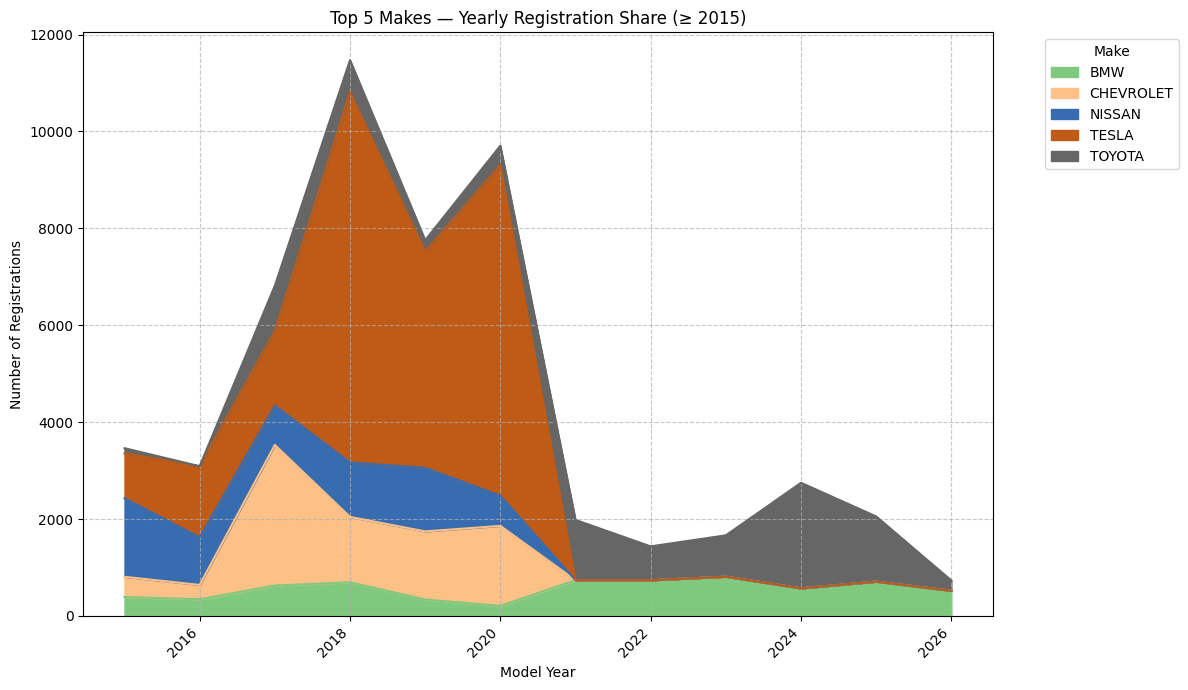

In [ ]:
# ----- 6.4 Top Make Share Over Time (Top 5) -----
print('=== Top 5 Makes — Yearly Registration Count ===')
top5 = df['Make'].value_counts().head(5).index.tolist()
make_yr = (
    df[df['Make'].isin(top5) & (df['Model Year'] >= 2015)]
    .groupby(['Model Year', 'Make'])
    .size()
    .unstack(fill_value=0)
)
print(make_yr.to_string())

# Plotting Top 5 Makes Share Over Time (Stacked Area Plot)
plt.figure(figsize=(12, 7))
make_yr.plot(kind='area', stacked=True, colormap='Accent', figsize=(12, 7))
plt.title('Top 5 Makes — Yearly Registration Share (≥ 2015)')
plt.xlabel('Model Year')
plt.ylabel('Number of Registrations')
plt.grid(linestyle='--', alpha=0.7)
plt.legend(title='Make', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 7. Geographic Concentration <a id='7'></a>

=== Top 15 Counties by EV Registrations ===
  King        : 46,605  ( 46.0%)
  Snohomish   : 10,718  ( 10.6%)
  Pierce      :  8,590  (  8.5%)
  Clark       :  6,814  (  6.7%)
  Thurston    :  4,103  (  4.1%)
  Kitsap      :  3,901  (  3.9%)
  Spokane     :  3,272  (  3.2%)
  Whatcom     :  3,084  (  3.0%)
  Benton      :  1,760  (  1.7%)
  Skagit      :  1,348  (  1.3%)
  Island      :  1,303  (  1.3%)
  Yakima      :    872  (  0.9%)
  Clallam     :    810  (  0.8%)
  Jefferson   :    736  (  0.7%)
  San Juan    :    719  (  0.7%)

Top 3 counties hold 65.1% of all registrations


/tmp/ipykernel_1374/2256034279.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=county_counts.index, y=county_counts.values, palette='magma')


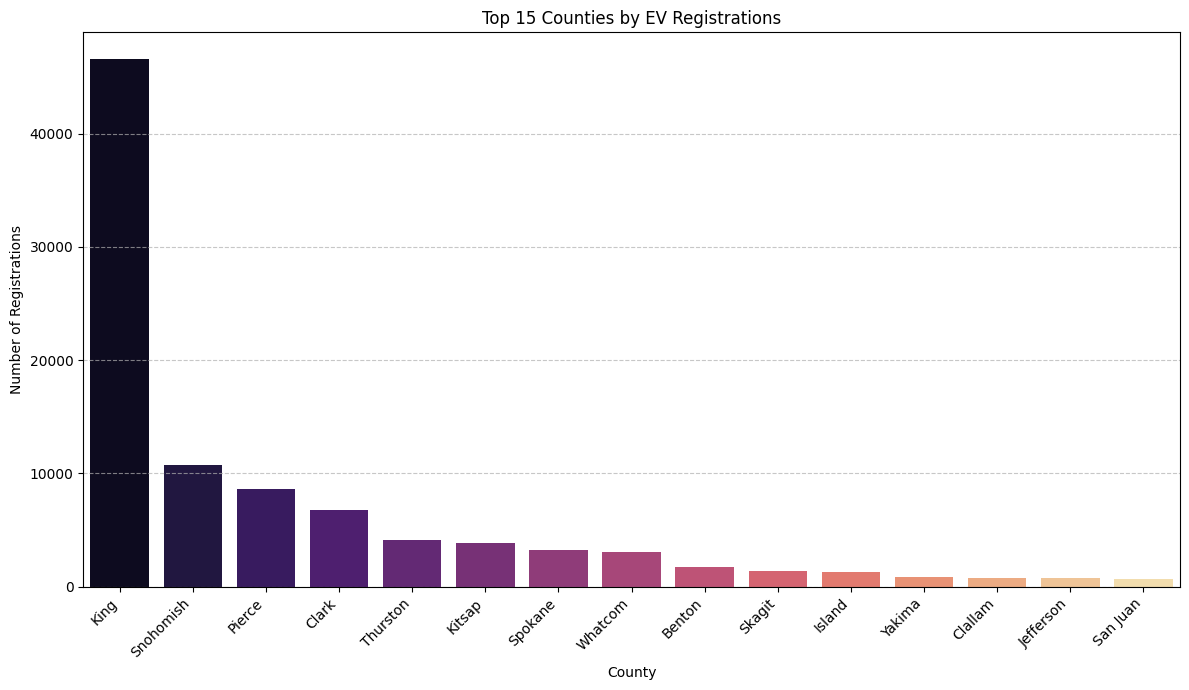

In [ ]:
# ----- 7.1 Top 15 Counties -----
print('=== Top 15 Counties by EV Registrations ===')
county_counts = df['County'].value_counts().head(15)

for county, cnt in county_counts.items():
    pct = cnt / len(df) * 100
    # Removed bar chart printing logic
    print(f'  {county:<12}: {cnt:>6,}  ({pct:5.1f}%)')

print()
top3_share = county_counts.head(3).sum() / len(df) * 100
print(f'Top 3 counties hold {top3_share:.1f}% of all registrations')

# Plotting Top 15 Counties
plt.figure(figsize=(12, 7))
sns.barplot(x=county_counts.index, y=county_counts.values, palette='magma')
plt.title('Top 15 Counties by EV Registrations')
plt.xlabel('County')
plt.ylabel('Number of Registrations')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

=== Top 15 Cities by EV Registrations ===
  Seattle             : 16,230  (16.0%)
  Vancouver           :  4,254  ( 4.2%)
  Bellevue            :  3,827  ( 3.8%)
  Olympia             :  2,668  ( 2.6%)
  Redmond             :  2,645  ( 2.6%)
  Renton              :  2,580  ( 2.5%)
  Kirkland            :  2,546  ( 2.5%)
  Tacoma              :  2,515  ( 2.5%)
  Bothell             :  2,347  ( 2.3%)
  Bellingham          :  2,153  ( 2.1%)
  Sammamish           :  2,077  ( 2.1%)
  Spokane             :  1,949  ( 1.9%)
  Everett             :  1,582  ( 1.6%)
  Tukwila             :  1,457  ( 1.4%)
  Kent                :  1,425  ( 1.4%)


/tmp/ipykernel_1374/3094183500.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_counts.index, y=city_counts.values, palette='rocket')


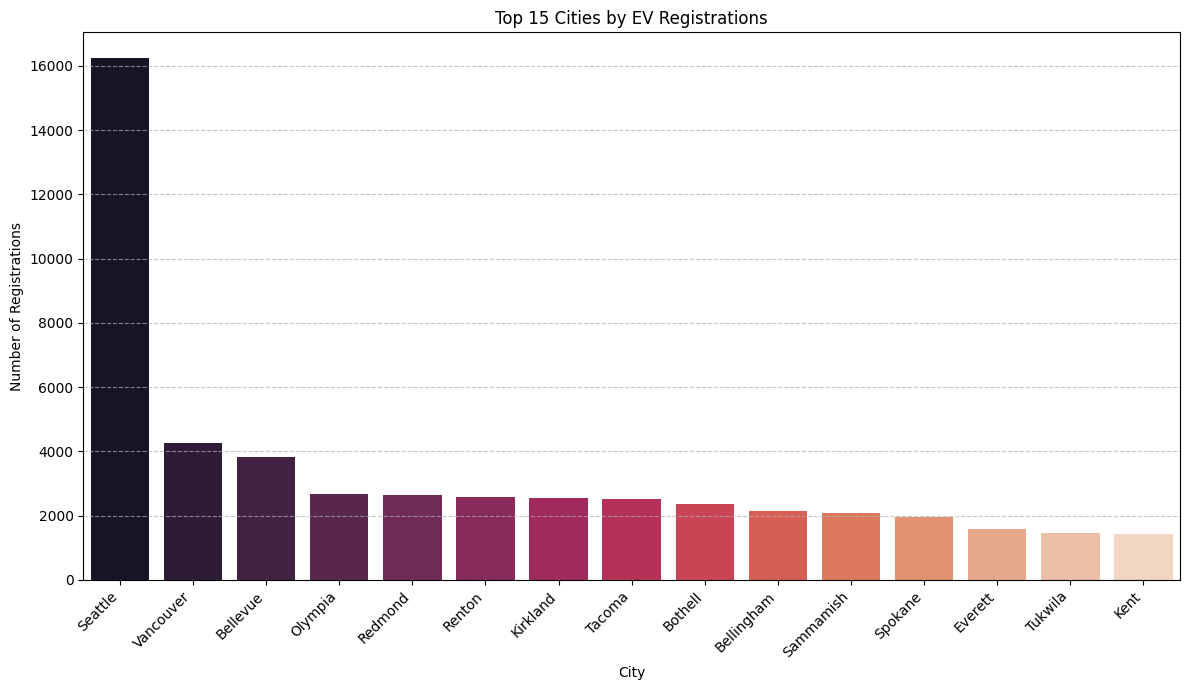

In [ ]:
# ----- 7.2 Top 15 Cities -----
print('=== Top 15 Cities by EV Registrations ===')
city_counts = df['City'].value_counts().head(15)

for city, cnt in city_counts.items():
    pct = cnt / len(df) * 100
    print(f'  {city:<20}: {cnt:>6,}  ({pct:4.1f}%)')

# Plotting Top 15 Cities
plt.figure(figsize=(12, 7))
sns.barplot(x=city_counts.index, y=city_counts.values, palette='rocket')
plt.title('Top 15 Cities by EV Registrations')
plt.xlabel('City')
plt.ylabel('Number of Registrations')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

=== EV Type Split — Top 5 Counties ===
             BEV   PHEV  Total  BEV_%
County                               
Clark       2737   4077   6814  40.20
King       21931  24674  46605  47.10
Pierce      3608   4982   8590  42.00
Snohomish   5226   5492  10718  48.80
Thurston    1770   2333   4103  43.10


<Figure size 1200x700 with 0 Axes>

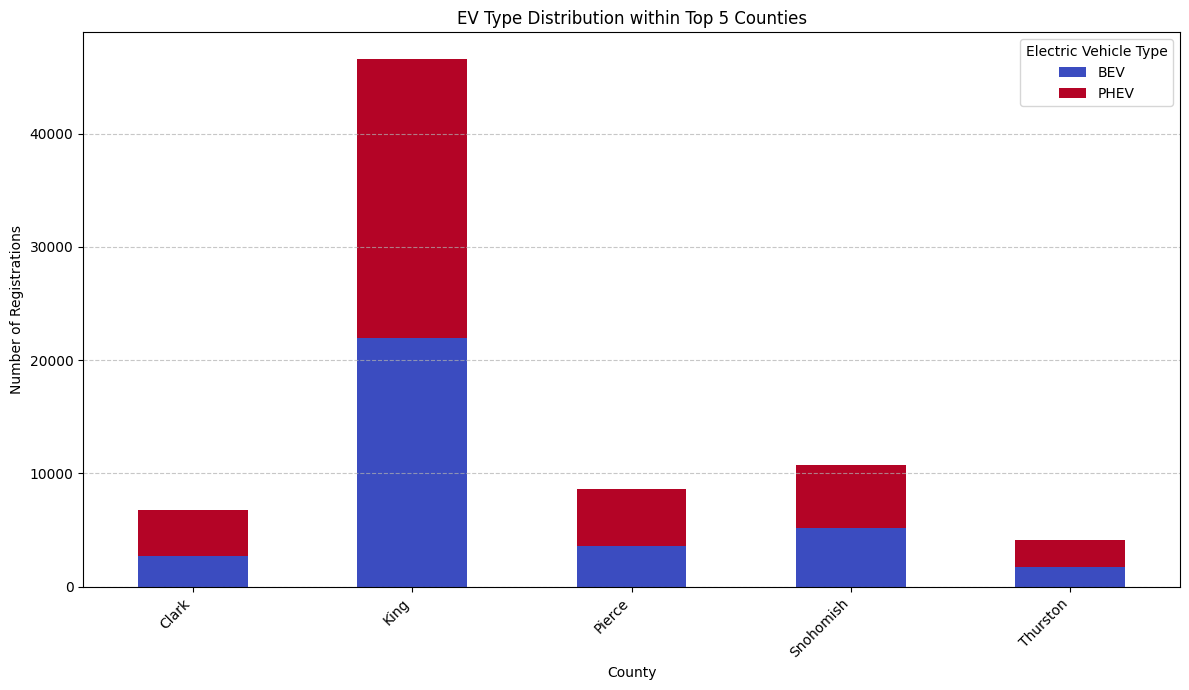

In [ ]:
# ----- 7.3 EV Type Distribution within Top 5 Counties -----
top5_counties = df['County'].value_counts().head(5).index

print('=== EV Type Split — Top 5 Counties ===')
county_type = (
    df[df['County'].isin(top5_counties)]
    .groupby(['County', 'Electric Vehicle Type'])
    .size()
    .unstack(fill_value=0)
)
county_type.columns = ['BEV', 'PHEV']
county_type['Total'] = county_type['BEV'] + county_type['PHEV']
county_type['BEV_%'] = (county_type['BEV'] / county_type['Total'] * 100).round(1)
print(county_type.to_string())

# Plotting EV Type Distribution within Top 5 Counties
county_type_plot = county_type[['BEV', 'PHEV']]
plt.figure(figsize=(12, 7))
county_type_plot.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(12, 7))
plt.title('EV Type Distribution within Top 5 Counties')
plt.xlabel('County')
plt.ylabel('Number of Registrations')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Electric Vehicle Type')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

=== Geographic Bounds (Lat / Long) ===
  Latitude  — Min: 13.5599, Max: 61.1899, Mean: 47.4051
  Longitude — Min: -156.4633, Max: 144.9083, Mean: -121.9572

Records outside WA bounding box: 278
           County            City State  Latitude  Longitude
30485      Oldham          Goshen    KY     38.40     -85.58
35558   San Diego     Chula Vista    CA     32.64    -116.96
37279   Riverside        Wildomar    CA     33.61    -117.26
38215   San Diego       Oceanside    CA     33.21    -117.29
39964  Sacramento  Rancho Cordova    CA     38.57    -121.30
40183     Laramie        Cheyenne    WY     41.13    -104.82
45310     Calvert          Owings    MD     38.72     -76.60
45652     Fairfax      Alexandria    VA     38.79     -77.08
47372      Orange      West Point    NY     41.40     -73.96
48908     Autauga      Prattville    AL     32.46     -86.45


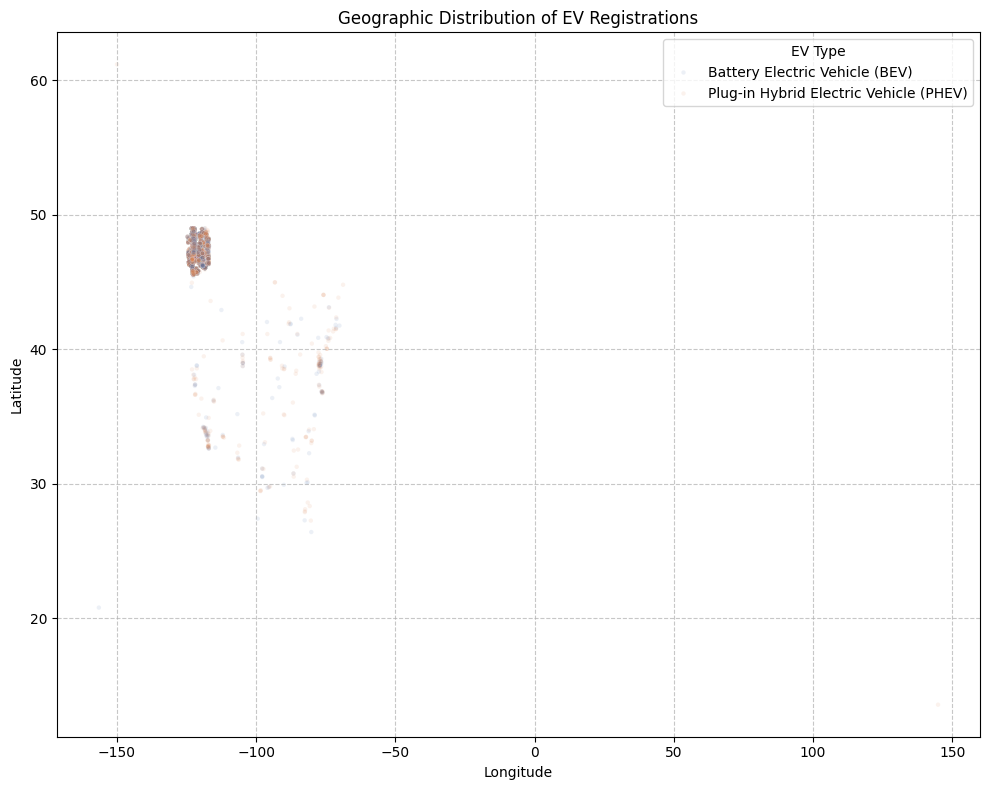

In [ ]:
# ----- 7.4 Geographic Spread — Lat/Long Stats -----
print('=== Geographic Bounds (Lat / Long) ===')
print(f'  Latitude  — Min: {df['Latitude'].min():.4f}, Max: {df['Latitude'].max():.4f}, Mean: {df['Latitude'].mean():.4f}')
print(f'  Longitude — Min: {df['Longitude'].min():.4f}, Max: {df['Longitude'].max():.4f}, Mean: {df['Longitude'].mean():.4f}')

# Flag out-of-Washington coordinates
# WA lat: ~45.5–49.0, lon: ~-124.7 to -116.9
out_of_wa = df[(df['Latitude'] < 45.5) | (df['Latitude'] > 49.5) |
               (df['Longitude'] < -125.0) | (df['Longitude'] > -116.5)]
print()
print(f'Records outside WA bounding box: {len(out_of_wa)}')
if len(out_of_wa) > 0:
    print(out_of_wa[['County','City','State','Latitude','Longitude']].head(10).to_string())

# Plotting Geographic Spread (Scatter plot of Latitude vs Longitude)
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Longitude', y='Latitude', data=df, alpha=0.1, s=10, hue='Electric Vehicle Type', palette='deep')
plt.title('Geographic Distribution of EV Registrations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(linestyle='--', alpha=0.7)
plt.legend(title='EV Type')
plt.tight_layout()
plt.show()

---
## 8. Outlier Detection <a id='8'></a>

In [ ]:
# ----- 8.1 IQR-based Outlier Detection -----
def iqr_outliers(series, name):
    q1  = np.percentile(series.dropna(), 25)
    q3  = np.percentile(series.dropna(), 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = series[(series < lower) | (series > upper)]
    pct = len(outliers) / len(series) * 100
    print(f'{name}')
    print(f'  Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}')
    print(f'  Bounds: [{lower:.2f}, {upper:.2f}]')
    print(f'  Outliers: {len(outliers):,} ({pct:.2f}%)')
    print()
    return outliers

print('=== IQR-based Outlier Detection ===')
out_range = iqr_outliers(df['Electric Range'], 'Electric Range')
out_age   = iqr_outliers(df['Vehicle Age'],    'Vehicle Age')
out_yr    = iqr_outliers(df['Model Year'],      'Model Year')

In [ ]:
# ----- 8.2 Z-score Outlier Detection -----
def zscore_outliers(series, name, threshold=3):
    mean = series.mean()
    std  = series.std()
    z    = np.abs((series - mean) / std)
    outliers = series[z > threshold]
    pct = len(outliers) / len(series) * 100
    print(f'{name}')
    print(f'  Mean={mean:.2f}, Std={std:.2f}')
    print(f'  |Z| > {threshold} outliers: {len(outliers):,} ({pct:.2f}%)')
    print()
    return outliers

print('=== Z-Score Outlier Detection (|Z| > 3) ===')
_ = zscore_outliers(df['Electric Range'], 'Electric Range')
_ = zscore_outliers(df['Vehicle Age'],    'Vehicle Age')
_ = zscore_outliers(df['Model Year'],      'Model Year')

In [ ]:
# ----- 8.3 Profile of Electric Range Outliers (IQR method) -----
if len(out_range) > 0:
    print('=== Electric Range Outlier Profiles ===')
    outlier_df = df.loc[out_range.index]
    print(outlier_df[['Make','Model','Model Year','Electric Vehicle Type','Electric Range']]
          .sort_values('Electric Range', ascending=False)
          .head(20)
          .to_string(index=False))
else:
    print('No IQR outliers detected in Electric Range — data appears well-bounded.')

In [ ]:
# ----- 8.4 Very Old Vehicles (potential data anomalies) -----
old_thresh = 2010
old_vehicles = df[df['Model Year'] < old_thresh]
print(f'=== Vehicles with Model Year < {old_thresh} ===')
print(f'Count: {len(old_vehicles)}')
print(old_vehicles[['Make','Model','Model Year','Electric Vehicle Type','Electric Range','County']]
      .sort_values('Model Year')
      .to_string(index=False))

In [ ]:
# ----- 8.5 Zero-range PHEV/BEV Records -----
zero_range = df[df['Electric Range'] == 0]
print(f'=== Vehicles with Electric Range = 0 ===')
print(f'Count: {len(zero_range)}')
if len(zero_range) > 0:
    print(zero_range['Electric Vehicle Type'].value_counts())
    print()
    print('These are typically PHEVs where range data was not reported.')

---
## 9. Key EDA Findings Summary <a id='9'></a>

In [ ]:
# Clean up temporary column added during analysis
df.drop(columns=['Range_Bin'], inplace=True, errors='ignore')

print('Temporary columns cleaned. Dataset shape:', df.shape)

### Summary of Key EDA Findings

| # | Finding | Detail |
|---|---------|--------|
| 1 | **Dataset is complete** | 101,275 records, 26 columns, zero missing values |
| 2 | **PHEV dominates slightly** | 55,692 PHEVs (55%) vs 45,583 BEVs (45%), but BEV share is rising sharply in recent years |
| 3 | **Tesla is #1 by large margin** | 24,182 registrations (23.9%) — nearly 2.5× the next brand (Chevrolet at 9,848) |
| 4 | **Range gap between BEV and PHEV is massive** | BEV mean: 200 miles vs PHEV mean: 32 miles |
| 5 | **Range has improved over time** | Mean range grew from ~75 miles (2013) to ~160+ miles (2024) |
| 6 | **Fleet is relatively young** | Median vehicle age: 7 years; most registrations are 2017–2025 |
| 7 | **Registration peaked in 2018** | 13,956 units in 2018; next peaks in 2020 (11,970) and 2024 (10,723) |
| 8 | **Highly geographically concentrated** | King County alone = 46% of fleet; top 3 counties = ~65% |
| 9 | **Fleet is Mass Market dominated** | 64% Mass Market vs 36% Luxury — but Luxury EVs have significantly higher range |
| 10 | **Growth Wave is dominant** | 50,163 vehicles in Growth phase; Early adopters (13,468) and Mass Adoption (37,644) |
| 11 | **No IQR outliers in Electric Range** | Distribution is bimodal (PHEV vs BEV cluster) but bounded — no erroneous extremes |
| 12 | **Very few pre-2010 EVs** | Only ~50 records before 2010 — negligible but valid (early EV experiments) |

---

**Next steps →** `04_statistical_analysis.ipynb` will:
- Perform correlation & regression analysis on Electric Range vs Model Year, Vehicle Age
- Conduct hypothesis testing (BEV vs PHEV range differences, County-level adoption differences)
- Validate distributional assumptions (normality tests, variance analysis)